# Import Statements (libraries + Functions)

In [1]:
import scipy.stats as stats


In [2]:
import numpy as np
import pandas as pd
import vcf
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import pickle
import scipy.stats
import scipy.stats as stats

%matplotlib inline

In [3]:
import ast

In [4]:
import screed
import mmh3

In [5]:
from Bio import SeqIO


In [6]:
import json

In [7]:
# https://bioframe.readthedocs.io/en/latest/guide-intervalops.html
import bioframe as bf
#import bioframe.vis

In [8]:
import subprocess

In [9]:
from pycirclize import Circos


In [10]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch


In [11]:
from matplotlib.ticker import FuncFormatter

# Function to convert base pairs to megabases
def bp_to_mb(x, pos):
    return f'{x * 1e-6:.1f}'

# Function to convert base pairs to kilobases

def bp_to_kb(x, pos):
    return f'{x * 1e-3:.0f}'

# Example usage
# axs[0].xaxis.set_major_formatter(FuncFormatter(bp_to_kb))
# axs[0].set_xlabel("Distance (kb)")


In [12]:
# Define matplotlib plot style from config file
plt.style.use('../mgm.v1.mplstyle')

In [13]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

#### Pandas Viewing Settings

In [14]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Import custom utils functions

In [15]:
%load_ext autoreload
%autoreload 2
    
from gcutils.general import Rv_dist, compute_Paralog_EdgeToEdge_Distance

from gcutils.eventtoparalogcomparison import genViz_RecombEvent_Vs_Paralogs_V3
from gcutils.eventtoparalogcomparison import process_and_visualize_event

# from gcutils.homologymapfuncs import label_HmMap_PAF_DF_ByOvrLapGenes, label_HmMap_Variants_DF_ByOvrLapGenes



### Import functions for plotting Gene Annotations + Results (GCEs + Epitopes, MutFreq, etc)

In [16]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

from gcutils.genomeviz_utils import plot_Anno_WiVariantCalls_2Panel, plot_Anno_with_empty_bottom

from gcutils.genomeviz_utils import add_cdseffect_legend, pack_intervals_greedy
from gcutils.genomeviz_utils import plot_multi_event_snp_packed_on_ax_V2, plot_Anno_with_GCE_V3

from gcutils.genomeviz_utils import plot_variants_for_isolates_simple
from gcutils.genomeviz_utils import plot_paralog_variants_on_ax
from gcutils.genomeviz_utils import plot_genome_annotation_on_ax

from gcutils.genomeviz_utils import overlay_gc_event_highlights_on_variants

from gcutils.genomeviz_utils import viz_region_Tree_Variants_Anno_ParalogVariants, viz_region_Tree_Variants_Anno


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import functions related to phylogeny/tree viz

In [17]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
    
from gcutils.gubbinsfuncs import get_BranchLengths_and_DescendantCounts_FromTree

from gcutils.gubbinsfuncs import annotate_tree_with_lineages, infer_InternalNode_Lineages

from gcutils.treeviz_mpl import mpl_plot_tree

from gcutils.treeviz_ete_utils import subset_tree_by_leaf_ids, subset_ETE_Tree
from gcutils.treeviz_ete_utils import style_ETE3_Tree_ByMtbLineage_V1

from gcutils.treeviz_ete_utils import style_single_node_in_tree
from gcutils.treeviz_ete_utils import subset_ETE_Tree_Style_GCEChildNode 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Define Functions

In [18]:
import re
import pandas as pd
import numpy as np

# reuse your existing regex
CS_OP_RE = re.compile(r'([:=*+-])(\d+|[A-Za-z]+)')

def count_substitutions_in_cs(cs: str) -> int:
    """
    Count the number of substitution events (*xy) in a minimap2 cs tag.

    Parameters
    ----------
    cs : str
        A single cs tag string (e.g. ':6-ata:10+gtc:4*at:3').

    Returns
    -------
    int
        Number of substitutions detected in this cs string.
    """
    if cs is None or (isinstance(cs, float) and pd.isna(cs)):
        return 0

    n_sub = 0
    for op, arg in CS_OP_RE.findall(cs):
        if op == '*':
            # arg is two bases: ref, query
            ref_base = arg[0]
            alt_base = arg[1]
            # mirror your variant logic: skip ambiguous Ns
            if ref_base.lower() != "n" and alt_base.lower() != "n":
                n_sub += 1

    return n_sub


In [19]:

def calculate_gc_content_perwindow(genome_seq, df,
                                   start_col = "Target_Start",
                                   end_col   = "Target_End"):
    """
    Compute GC content for each genomic window in the DataFrame.
    
    Parameters:
    - genome (str): The full genome sequence as a string.
    - df (pd.DataFrame): DataFrame containing "Target_Start" and "Target_End" columns.
    
    Returns:
    - pd.DataFrame: Updated DataFrame with a new column "GC_Content".
    """
    gc_contents = []
    
    for _, row in df.iterrows():
        start = int(row[start_col]) - 1  # Convert to 0-based indexing
        end = int(row[end_col])
        
        # Extract sequence from genome string
        subseq = genome_seq[start:end]
        
        # Calculate GC content
        gc_count = subseq.count('G') + subseq.count('C')
        total_bases = len(subseq)
        gc_content = (gc_count / total_bases) * 100 if total_bases > 0 else None
        
        gc_contents.append(gc_content)

    # Add results to DataFrame
    df["GC_Content"] = gc_contents
    df["GC_Content"] = df["GC_Content"].astype(float)

    return df



## ETE3 Settings & Parameters Setup

### Link to ETE3 documentation for tree layout style
 http://etetoolkit.org/docs/latest/tutorial/tutorial_drawing.html#interactive-visualization-of-trees

In [20]:

import ete3 as ETE

from ete3 import Tree

# https://github.com/ipython/ipython/issues/10627
import os
os.environ['QT_QPA_PLATFORM']='offscreen'

In [21]:
Mtb_LinToColor_Dict = {"lineage1": "#DF83AC",
                      "lineage2": "#7098CB",
                      "lineage3": "#815D9F",
                      "lineage4": "#E76956",
                      "lineage5": "#B67548",
                      "lineage6": "#6AB79E",
                      "lineage8": "#E4515B", 
                      "None": "black",}


In [22]:

ts_vt_NoScale = ETE.TreeStyle()
ts_vt_NoScale.show_leaf_name = False
ts_vt_NoScale.show_branch_length = False
ts_vt_NoScale.show_branch_support = False
ts_vt_NoScale.show_scale = False #True
ts_vt_NoScale.branch_vertical_margin = 2
ts_vt_NoScale.rotation = 90

ts_hz_NoScale = ETE.TreeStyle()
ts_hz_NoScale.show_leaf_name = False
ts_hz_NoScale.show_branch_length = False
ts_hz_NoScale.show_branch_support = False
ts_hz_NoScale.show_scale = False #True
ts_hz_NoScale.branch_vertical_margin = 2
ts_hz_NoScale.rotation = 0

ts_ColLin = ETE.TreeStyle()
ts_ColLin.show_leaf_name = False
ts_ColLin.show_branch_length = False
ts_ColLin.show_branch_support = False
ts_ColLin.show_scale = True #True
ts_ColLin.branch_vertical_margin = 2
#ts_ColLin.layout_fn = Mtb_ColorBranchByLineage_Layout
ts_ColLin.rotation = 90

ts_ColLin_circ = ETE.TreeStyle()
ts_ColLin_circ.mode = "c" # draw tree in circular mode
ts_ColLin_circ.arc_start = 0 #-180 # 0 degrees = 3 o'clock
ts_ColLin_circ.arc_span = 180
ts_ColLin_circ.show_leaf_name = False
ts_ColLin_circ.show_branch_length = False
ts_ColLin_circ.show_branch_support = False
ts_ColLin_circ.show_scale = False #True
ts_ColLin_circ.branch_vertical_margin = 2
#ts_ColLin_circ.layout_fn = Mtb_ColorBranchByLineage_Layout

ts_ColLin_FullCirc = ETE.TreeStyle()
ts_ColLin_FullCirc.mode = "c" # draw tree in circular mode
ts_ColLin_FullCirc.arc_start = -90 #-180 # 0 degrees = 3 o'clock
ts_ColLin_FullCirc.arc_span = 355
ts_ColLin_FullCirc.show_leaf_name = False
ts_ColLin_FullCirc.show_branch_length = False
ts_ColLin_FullCirc.show_branch_support = False
ts_ColLin_FullCirc.show_scale = False #True
ts_ColLin_FullCirc.branch_vertical_margin = 2
# ts_ColLin_FullCirc.rotation = 90


# Define Color Pallete `Mtb-H37Rv` Gene Categories 

In [23]:
all_categories = [ "PE/PPE", "REP13E12_Repeat", "esx", "conserved hypotheticals", "cell wall and cell processes",
                  "insertion seqs and phages",
                  "intermediary metabolism and respiration", "lipid metabolism", "information pathways",
                  "virulence, detoxification, adaptation", "regulatory proteins",
                   "stable RNAs",  "unknown",  ] 

NQ_Colors = ['065275', '029099', '7CCBA1', 'FDDE9C', 'F0746E', 'DC3978', '7C1E6F']


Mtb_GeneCat_ColorDict = { 
    "PE/PPE" : "#57A89D", #"#1ABFAD", 
    "REP13E12_Repeat" : "#D3516D", 
    "esx" : "#5D81AA", 
    "lipid metabolism" : "#6EA4D4",  # Warm brownish-orange
    "conserved hypotheticals" : "#F2B84A", 
    "cell wall and cell processes" : "#7D3E84", 
    "insertion seqs and phages": "#E16843", 
    "intermediary metabolism and respiration" : "#4F7942",  # Deep green
    "information pathways": "#5698C4",  # Soft blue
    "virulence, detoxification, adaptation": "#B0338E",  # Magenta-purple
    "regulatory proteins": "#A42CD6",  # Vivid violet
    "stable RNAs": "#5C5C5C",  # Neutral dark gray
    "unknown": "#999999",  # Lighter gray for unknown
}

Mtb_GeneCat_ColorPallete =  [Mtb_GeneCat_ColorDict[cat] for cat in all_categories] 

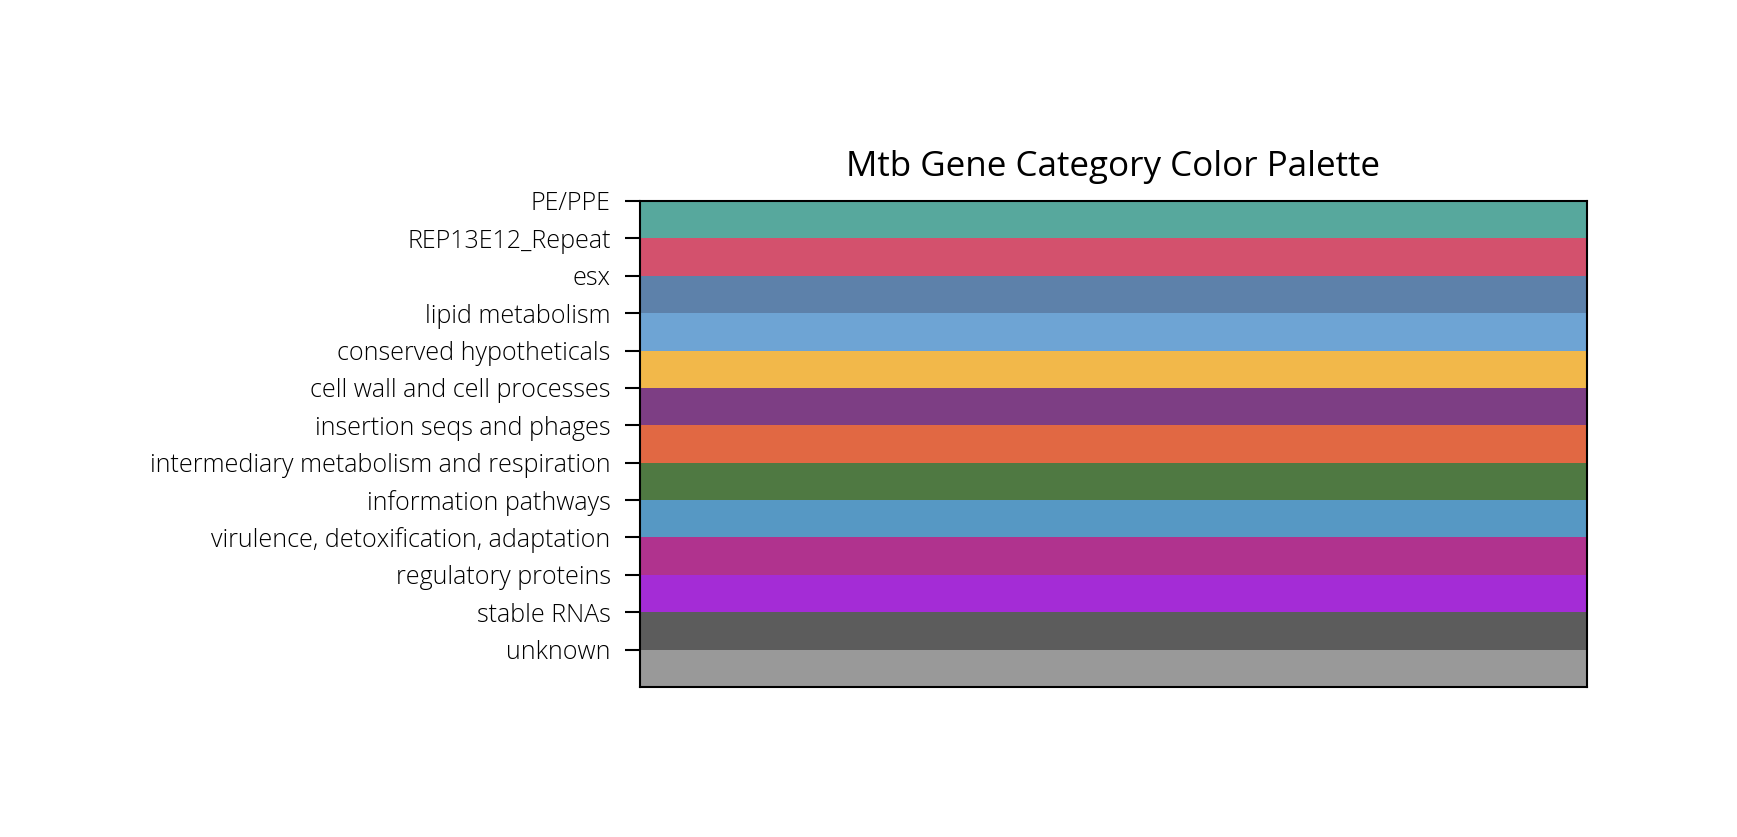

In [24]:
# Plot the colors
fig, ax = plt.subplots(figsize=(5, 2))
ax.set_xlim(0, 1)
ax.set_ylim(0, len(Mtb_GeneCat_ColorDict))
ax.set_xticks([])
ax.set_yticks(range(len(Mtb_GeneCat_ColorDict)))
ax.set_yticklabels(Mtb_GeneCat_ColorDict.keys(), fontsize=6)

for i, (category, color) in enumerate(Mtb_GeneCat_ColorDict.items()):
    ax.add_patch(plt.Rectangle((0, i), 1, 1, color=color))

plt.gca().invert_yaxis()
plt.title("Mtb Gene Category Color Palette")
plt.show()

# Pre-process Data for Genome Viz w/ `DNA-Features-Viewer`

### Import/setup DNA Features Viewer (For plotting H37rv genome annotations)

In [25]:
from dna_features_viewer import GraphicFeature, GraphicRecord, CircularGraphicRecord, BiopythonTranslator
from Bio import SeqIO
from Bio.SeqFeature import SeqFeature, FeatureLocation


In [26]:
BiopythonTranslator.label_fields = ['gene', 'label', 'source', 'locus_tag', 'note', 'gene', 'product']
BiopythonTranslator.ignored_features_types = ["source", "gene"]
BiopythonTranslator.default_feature_color = "lightgrey"

## Create H37Rv Genome Record + Results Features Objects

In [27]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"

In [28]:
records = list(SeqIO.parse(H37rv_Ref_GBK_PATH, "genbank"))
print(len(records))
Mtb_H37rv_SeqIO_Record = records[0]

CDS_Features = []

for feature in Mtb_H37rv_SeqIO_Record.features:
    if feature.type == "CDS":
        CDS_Features.append(feature) 
        # if "gene" in feature.qualifiers.keys():
        #     if feature.qualifiers["locus_tag"] == ['Rv1196']:
        #         print(feature)
        #         print()

# --- Manually add esxM (Rv1792) ---

# esxM gene info
esxM_start = 2030346  # GenBank is 0-based, so subtract 1 from 1-based start
esxM_end = 2030643    # end is exclusive in Biopython
esxM_seq = (
    "atggcctcacgttttatgacggatccgcatgcgatgcgggacatggcgggccgttttgaggtgcacgcccagacggtggaggacgaggctcgccggatgtgggcgtccgcgcaaaacatttccggtgcgggctggagtggcatggccgaggcgacctcgctagacaccatgacctagatgaatcaggcgtttcgcaacatcgtgaacatgctgcacggggtgcgtgacgggctggttcgcgacgccaacaactacgaacagcaagagcaggcctcccagcagatcctgagcagctag"
)

# Create the SeqFeature object
esxM_feature = SeqFeature(
    location=FeatureLocation(esxM_start, esxM_end, strand=1),
    type="CDS",
    qualifiers={
        "locus_tag": ["Rv1792"],
        "gene": ["esxM"],
        "product": ["esxM hypothetical protein"],
        "translation": [
            "MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMTMNQAFRNIVNMLHGVRDGLVRDANNYEQQEQASQQILSS"
        ]
    }
)

# Append to the list of CDS features
CDS_Features.append(esxM_feature)

Mtb_H37rv_SeqIO_Record.features = CDS_Features

Mtb_H37rv_Graphic_Record = BiopythonTranslator().translate_record(Mtb_H37rv_SeqIO_Record)
Mtb_H37rv_Graphic_Record.feature_level_height = 0

1


# Parse `Mtb151CI` Isolate Metadata

In [29]:
Repo_DataDir = "../../Data"
InputAsmPath_Dir = f"{Repo_DataDir}/231121.InputAsmTSVs.MtbSetV3.151CI"

MtbSetV3_151CI_InputAsmPATHs_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAndSRAsm.FAPATHs.V1.tsv"
MtbSetV3_151CI_AsmSumm_TSV = f"{InputAsmPath_Dir}/231121.MtbSetV3.151CI.HybridAsm.AsmSummary.V2.tsv"


### Reading in "WGA151CI_AsmSummary_DF"

In [30]:
WGA151CI_AsmSummary_DF = pd.read_csv(MtbSetV3_151CI_AsmSumm_TSV, sep = "\t")

SampleIDs_151CI_SOI = list( WGA151CI_AsmSummary_DF["SampleID"].values )
WGA151CI_SampleIDs = SampleIDs_151CI_SOI
WGA151CI_AsmSummary_DF.shape


(151, 7)

#### Create SampleID Mapping Dicts

In [31]:
WGA151CI_ID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
WGA151CI_ID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
WGA151CI_ID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  

SampleID_To_PrimLineage_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'PrimaryLineage']].values)
SampleID_To_SubLineage_Dict = dict( WGA151CI_AsmSummary_DF[["SampleID", "Lineage"]].values)
SampleID_To_Dataset_Dict = dict(WGA151CI_AsmSummary_DF[['SampleID', 'Dataset_Tag']].values)  


In [32]:
WGA151CI_OrderOfSampleIDs_Phylo = ['N0153', 'N0072', 'mada_2-46', 'mada_1-44', 'mada_107', 'mada_1-1', 'mada_1-51',
                          'mada_1-39', 'mada_1-36', 'mada_117', 'mada_122', 'mada_118', 'mada_1-10', 'R27252',
                          'R23887', 'TB3091', '9050-05', '3003-06', '702-06', '696-05', '8651-04', 'TB3396',
                          '4549-04', 'TB1612', 'TB2780', 'TB3368', 'TB1236', 'TB2659', '8129-04', 'R30215',
                          'R25048', 'TB2512', 'TB2981', 'TB2995', 'TB3113', '706-05', 'R30078', 'R28012',
                          'R27657', 'R30234', 'R31095', 'R28703', 'R24120', 'R36431', 'R29816', 'S0070-08',
                          'N0155', 'N0145', 'R29598', 'R24100', 'S0107-01', 'R28581', 'S0256-08', 'S0085-01',
                          'S0089-01', 'mada_1-11', 'M0003941_3', 'mada_115', 'mada_2-42', 'R37765', '18_0621851',
                          'R22601', 'R27937', 'R18040', 'R18043', 'R27725', 'R26791', 'R20574', 'R20260', 'R21408',
                          'R23146', 'R28980', 'R32929', 'R26778', 'R30420', 'R21893', 'QC-9', 'QC-5', 'QC-3', 'N0004',
                          'mada_1-30', 'N0054', 'N1274', '01_R1134', 'TB2968', 'mada_1-53', 'mada_2-53', 'mada_1-50',
                          'mada_2-1', 'R23571', 'mada_123', 'mada_1-12', 'mada_1-15', 'mada_128', 'mada_1-38', 'TB3054',
                          'mada_126', 'mada_120', 'TB4620', 'M0016737_0', 'M0016395_7', 'R15311', 'TB2661', 'TB3386',
                          'TB3162', '02_R1179', 'M0010874_7', 'QC-7', 'QC-6', 'QC-1', '01_R1430', 'M0011368_9',
                          '02_R1896', 'mada_2-25', 'TB3237', 'mada_103', 'mada_112', 'mada_124', 'S0123-01', 'S0262-02',
                          'TB3251', 'M0017522_5', 'R30396', 'R20896', 'mada_1-32', 'S0106-01', 'R21839', 'R21363', 'R21770',
                          'MT_0080', 'mada_102', 'TB3334', 'M0014888_3', 'mada_151', 'TB3169', 'mada_105', 'QC-8', 'QC-10',
                          'QC-4', 'mada_129', 'mada_139', '02_R1708', '02_R0894', 'mada_2-31', 'mada_1-41', 'N1272', 'N1176',
                          'N1202', 'N0091', 'N1177', 'RW-TB008']


# Parse all individual variants per genome annotated by CDS effect (`WGA-151CI`)

In [33]:
Mtb151_AllVar_Dir = "../../Data/241030.Mtb151CI.AllVariants.Anno.V1/"

Mtb151_AllVar_TSVGZ              = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.V1.tsv.gz"
Mtb151_AllVar_WiCDSAnno_TSVGZ    = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllVariants.WiCDSAnno.V1.tsv.gz"
Mtb151_SNPs_WiInterSNPDist_TSVGZ = f"{Mtb151_AllVar_Dir}/Mtb.151CI.AllSNPs.WiInterSNPDists.V1.tsv"


In [34]:

Mtb151CI_AllAsm_AllVar_DF = pd.read_csv(Mtb151_AllVar_WiCDSAnno_TSVGZ, sep="\t")

# WGA151_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF = Mtb151CI_AllAsm_AllVar_DF
AllAsm_AllVar_DF.shape

(260869, 20)

In [35]:
AllAsm_AllVar_DF["SampleID"].nunique()

151

# Parse HHRs tested for Enrichment of "Paralog-Matching" SNPs

In [36]:
HHR_TestForParalogSNPs_TSV = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb-GeneConv/mtb-GE-analysis/Analysis/4_Mtb_HHR_MutAttributes_V3/HHR.TestedForParalogSNPS.V1.tsv"

HHR_SNP_Sig_DF  = pd.read_csv(HHR_TestForParalogSNPs_TSV,
                              sep = "\t")

HHR_SNP_Sig_DF["Num_Overlap_Genes"] = HHR_SNP_Sig_DF["Overlap_Genes"].str.split(",").apply(len)

HHR_SNP_Sig_DF.shape

(21, 32)

In [37]:
HHR_SNP_Sig_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,NPossible_SNPs_Total,NPossible_ParalogSNPs,NObserved_SNPs_Total,NObserved_SNPs_MatchParalogSNP,p_value,log_p_value,neglog_p_value,NExpected_MatchParalogSNP,p_corr,neglog_p_corr,NucDivHotspot_Ovrlap,FoldEnrichment,LogFoldEnrichment,Log2FoldEnrichment,AbsEnrichment,SizeFactor,Num_Overlap_Genes
0,34,NC_000962.3,889019,891461,890240.0,2442,"Rv0795,Rv0796,Rv0797",3,15,1,0,34,PR_HmRegion_034,2,PR_Set_24,7326,1,29,7,0.0,500.0,500.0,0.003959,1.000000e-40,500.0,0,1768.344828,3.247567,10.788184,6.996041,0.109375,3
1,123,NC_000962.3,2828493,2829936,2829214.5,1443,Rv2512c,1,5,4,0,123,PR_HmRegion_123,0,PR_Set_30,4329,4,41,14,0.0,500.0,500.0,0.037884,1.000000e-40,500.0,0,369.548780,2.567672,8.529621,13.962116,0.218750,1
2,131,NC_000962.3,2982934,2983854,2983394.0,920,"Rv2665,Rv2666",1,5,5,0,131,PR_HmRegion_131,0,PR_Set_30,2760,3,25,6,0.0,500.0,500.0,0.027174,1.000000e-40,500.0,0,220.800000,2.343999,7.786596,5.972826,0.093750,2
3,55,NC_000962.3,1341295,1342730,1342012.5,1435,Rv1199c,1,5,4,0,55,PR_HmRegion_055,0,PR_Set_30,4305,4,38,7,0.0,500.0,500.0,0.035308,1.000000e-40,500.0,1,198.256579,2.297228,7.631225,6.964692,0.109375,1
4,157,NC_000962.3,3381311,3382749,3382030.0,1438,Rv3023c,1,5,3,0,157,PR_HmRegion_157,0,PR_Set_30,4314,3,45,4,0.0,500.0,500.0,0.031293,1.000000e-40,500.0,0,127.822222,2.106606,6.997995,3.968707,0.062500,1


# Import/parse processed H37rv genome annotations

In [38]:
RepoRef_Dir = "../../References"

AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir = f"{RepoRef_Dir}/201027_H37rv_AnnotatedGenes_And_IntergenicRegions"
#H37Rv_GenomeAnnotations_Genes_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.tsv"
H37Rv_GenomeAnnotations_Genes_V2_TSV = f"{AnnotatedGenes_And_IntergenicRegions_RepoRef_Dir}/H37Rv_GenomeAnnotations.Genes.V2.tsv"

## H37Rv Gene Annotations TSV
H37Rv_GenomeAnno_Genes_DF = pd.read_csv(H37Rv_GenomeAnnotations_Genes_V2_TSV, sep = "\t")
H37Rv_GeneInfo_Subset_DF = H37Rv_GenomeAnno_Genes_DF[["H37rv_GeneID", "Symbol", "Feature", "Functional_Category", "Is_Pseudogene", "Product", "PEandPPE_Subfamily", "ExcludedGroup_Category"]]

RvID_To_Symbol_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['H37rv_GeneID', 'Symbol']].values)
Symbol_To_RvID_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'H37rv_GeneID']].values)
Symbol_To_FuncCat_Dict = dict(H37Rv_GenomeAnno_Genes_DF[['Symbol', 'Functional_Category']].values)

ESX_Genes_List_TSV = f"{RepoRef_Dir}/190927_H37rv_ListOf_ESXgenes.tsv"
Esx_Genes_DF = pd.read_csv(ESX_Genes_List_TSV, sep = '\t')

In [39]:
H37Rv_GenomeAnno_Genes_DF.head(1)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways


### Define paths to H37Rv genome masking schemes

In [40]:
RepoRef_Dir = "../../References"

MaskingSchemes_Dir = f"{RepoRef_Dir}/Mtb_H37Rv_MaskingSchemes"
PLC_Scheme_BED = f"{MaskingSchemes_Dir}/201027_Mtb_H37rv_pLC_Regions_CoscollaExcludedGenes.bed"


### Define relevant H37Rv gene lists for analysis (PE/PPE, Esx, 13E12 gene)

In [41]:
ListOf_Esx_Symbols = list(Esx_Genes_DF["symbol"].values)
ListOf_Esx_RvIDs = list(Esx_Genes_DF["gene_id"].values)

In [42]:
listOf_PEPPE_Symbols = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["Symbol"].values )
listOf_PEPPE_RvIDs = list( H37Rv_GenomeAnno_Genes_DF.query(" Functional_Category == 'PE/PPE' ")["H37rv_GeneID"].values )

In [43]:
listOf_13E12_Region_RvIDs = ["Rv0094c", "Rv0095c", "Rv0393", "Rv1572c", "Rv1572c", "Rv1128c", "Rv1148c", "Rv1587c", "Rv1588c", "Rv1702c", "Rv1945", "Rv2100", "Rv3466", "Rv3467"]  


# Parse H37Rv Reference sequences (Genome, Genes, Proteins)

## Parse H37Rv genome sequence (DNA)

In [44]:
from Bio import SeqIO


In [45]:
H37rv_Ref_GBK_PATH = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.gbk"
H37Rv_FA = "/n/data1/hms/dbmi/farhat/mm774/References/GCF_000195955.2_ASM19595v2_genomic.fasta"

H37Rv_Seq = SeqIO.read(H37Rv_FA, "fasta").seq
len(H37Rv_Seq)

4411532

## Parse H37Rv Protein (AA) and gene (DNA) sequences

In [46]:
O2_RefDir = "/n/data1/hms/dbmi/farhat/mm774/References"

MycoBrowser_RefFiles_Dir = f"{O2_RefDir}/190619_Mycobrowser_H37rv_ReferenceFiles"

H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37Rv_Proteins_MycoBro_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta"
H37Rv_Proteins_NCBI_FAA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta"
H37RV_Genes_FA = f"{MycoBrowser_RefFiles_Dir}/Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta"



H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.faa"
H37Rv_FAA_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_proteins.esxM_Added.faa"
H37Rv_GBK_PATH = f"{O2_RefDir}/GCF_000195955.2_ASM19595v2_genomic.gbk"


In [47]:
!ls -1 $MycoBrowser_RefFiles_Dir

Mycobacterium_tuberculosis_H37Rv_genes_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta
Mycobacterium_tuberculosis_H37Rv_genome_v3.fasta.fai
Mycobacterium_tuberculosis_H37Rv_gff_v3.gff
Mycobacterium_tuberculosis_H37Rv_gff_v3.REP13E12_Regions.gff
Mycobacterium_tuberculosis_H37Rv_proteins_v3.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.esxM_Added.fasta
Mycobacterium_tuberculosis_H37Rv_proteins_v3_TrimmedHeader.fasta
Mycobacterium_tuberculosis_H37Rv_txt_v3_PEPPE_subfamilies.txt
Mycobacterium_tuberculosis_H37Rv_txt_v3.txt.tsv


### Parse MycoBrowser Protein Seq Ref

In [48]:
dictOf_H37Rv_MycoBrow_ProtSeq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_Proteins_MycoBro_FAA, "fasta"))):
    ShortID = record.name
    
    dictOf_H37Rv_MycoBrow_ProtSeq[ShortID] = record.seq


4091it [00:00, 130477.98it/s]


### Parse MycoBrowser Gene Seq Ref

In [49]:
dictOf_H37Rv_MycoBrow_Gene_Seq = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37RV_Genes_FA, "fasta"))):

    ShortID = record.name.split("|")[0]
    dictOf_H37Rv_MycoBrow_Gene_Seq[ShortID] = record.seq


4187it [00:00, 68282.40it/s]


In [50]:
list(dictOf_H37Rv_MycoBrow_Gene_Seq.keys())[:2]

['Rv3728', 'Rv3729']

### Parse NCBI Protein Seq Ref

In [51]:
dictOf_H37Rv_ProtSeq = {}
dictOf_H37Rv_ProtRecord = {}

for index, record in tqdm(enumerate(SeqIO.parse(H37Rv_FAA_PATH, "fasta"))):
    Rec_Description = record.description
    dict_Attr = {}
    for i in Rec_Description.split(" "):
        ###Just looking for line with " " character (as key = value)
        if "=" in i:
            key = i.strip().split("=")[0].strip('"').strip('[')
            value = i.strip().split("=")[1].strip('"').strip(']')
            ###Put them in a dictionnary
            dict_Attr[key]=value
    
    ShortID = dict_Attr["locus_tag"]
    dictOf_H37Rv_ProtSeq[ShortID] = record.seq
    dictOf_H37Rv_ProtRecord[ShortID] = record


3907it [00:00, 22691.16it/s]


In [52]:
#dictOf_H37Rv_ProtSeq["Rv1196"]

In [53]:
#dictOf_H37Rv_ProtSeq["Rv1196"] == dictOf_H37Rv_MycoBrow_ProtSeq["Rv1196"]

In [54]:
dictOf_H37Rv_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

In [55]:
dictOf_H37Rv_MycoBrow_ProtSeq["Rv1792"]

Seq('MASRFMTDPHAMRDMAGRFEVHAQTVEDEARRMWASAQNISGAGWSGMAEATSLDTMT')

# Parse in H37Rv Homology-Map Results (k19w19)

### Define all HmMap file paths

In [56]:
Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V9"

H37_Rv_MM2_HomologyMapping_Dir = f"{Main_Project_Dir}/250901.H37Rv.HomologyMapping.k19w19.ProcessedData.V2"

# Define paths to output TSVS

### Homologous regions (MERGED)
RvHmMap_Merged_ParaRegions_TSV  = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.ParalogousRegions.k19w19.tsv"
RvHmMap_Merged_LocalRepeats_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.MergedRegions.LocalRepeats.k19w19.tsv"

### Homology map (pairwise alignments)
RvHmMap_Aln_All_TSV           = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.All.tsv"
RvHmMap_Aln_PRs_NoOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.tsv"
RvHmMap_Aln_LRs_WiOverlap_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.WiOverlap.tsv"

RvHmMap_Aln_PRs_NoOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.NoOverlap.Clustered.tsv"
RvHmMap_Aln_LRs_WiOverlap_Clustered_TSV     = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.Aln.OnlyOverlap.Clustered.tsv"

### Variants from the homology map alignments
RvHmMap_Var_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.tsv"
RvHmMap_Var_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.snps.tsv"



### Variants from the homology map alignments (For each pairwise alignment between PRs)
RvHmMap_Var_PerAln_TSV      = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.tsv"
RvHmMap_Var_PerAln_SNPs_TSV = f"{H37_Rv_MM2_HomologyMapping_Dir}/RvHmMap.k19w19.variants.ParalogousRegions.PerAln.snps.tsv"



### Parse in HmRegions (`Paralogous_Regions` and `Local_Repeats`)

In [57]:
HmMapRegs_ParaRegs_k19w19_DF = pd.read_csv(RvHmMap_Merged_ParaRegions_TSV,
                                           sep="\t")

HmMapRegs_ParaRegs_k19w19_DF.shape

(200, 15)

In [58]:
HmMapRegs_LocalRepeats_k19w19_DF = pd.read_csv(RvHmMap_Merged_LocalRepeats_TSV, 
                                               sep="\t")
HmMapRegs_LocalRepeats_k19w19_DF.shape

(50, 13)

In [59]:
HmMapRegs_All_LRsPRs_K19w19_DF = pd.concat([HmMapRegs_ParaRegs_k19w19_DF,
                                            HmMapRegs_LocalRepeats_k19w19_DF])

HmMapRegs_All_LRsPRs_K19w19_DF.shape

(250, 15)

#### Peak at head of each HmMap Regions DFs

In [60]:
HmMapRegs_ParaRegs_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1
1,1,NC_000962.3,80623,82664,81643.5,2041,"Rv0072,Rv0073",0,1,1,1,1,PR_HmRegion_001,0,PR_Set_2
2,2,NC_000962.3,103705,105130,104417.5,1425,"Rv0094c,Rv0095c",0,2,2,2,2,PR_HmRegion_002,0,PR_Set_3
3,3,NC_000962.3,149571,149808,149689.5,237,PE_PGRS2,0,1,1,1,3,PR_HmRegion_003,0,PR_Set_4
4,4,NC_000962.3,177203,177447,177325.0,244,_,0,1,1,1,4,PR_HmRegion_004,0,PR_Set_5


In [61]:
HmMapRegs_LocalRepeats_k19w19_DF.head()

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID
0,0,NC_000962.3,333811,335879,334845.0,2068,PE_PGRS3,0,1,1,1,0,LR_HmRegion_000
1,1,NC_000962.3,366430,375121,370775.5,8691,"PPE5,PPE6",0,6,6,6,1,LR_HmRegion_001
2,2,NC_000962.3,424011,432951,428481.0,8940,"hspR,PPE7,PPE8",0,5,4,4,2,LR_HmRegion_002
3,3,NC_000962.3,566288,580814,573551.0,14526,"hbhA,Rv0476,Rv0477,deoC,Rv0479c,Rv0480c,Rv0481...",0,4,2,1,3,LR_HmRegion_003
4,4,NC_000962.3,631298,631436,631367.0,138,Rv0538,0,2,2,2,4,LR_HmRegion_004


### Parse in homology-map DFs (pairwise alignments between all homologous regions)

In [62]:
HmMap_Aln_k19w19_DF = pd.read_csv(RvHmMap_Aln_All_TSV,
                           sep="\t")
HmMap_Aln_k19w19_DF.shape

(776, 25)

In [63]:
HmMap_Aln_k19w19_NoOverlap_DF = pd.read_csv(RvHmMap_Aln_PRs_NoOverlap_TSV,
                                     sep="\t")
HmMap_Aln_k19w19_NoOverlap_DF.shape

(640, 38)

In [64]:
HmMap_Aln_k19w19_LocalRepeat_DF = pd.read_csv(RvHmMap_Aln_LRs_WiOverlap_TSV,
                                              sep="\t")
HmMap_Aln_k19w19_LocalRepeat_DF.shape

(136, 35)

### Parse in HomologyMap Alignment Variants DFs

In [65]:
### paralog variants - Improved per alignment `cs` tag approach 
Mtb_HM_Var_PR_DF = pd.read_csv(RvHmMap_Var_PerAln_TSV, sep="\t")
print(Mtb_HM_Var_PR_DF.shape)

Mtb_HM_Var_PR_SNPs_DF = pd.read_csv(RvHmMap_Var_PerAln_SNPs_TSV, sep="\t")
print(Mtb_HM_Var_PR_SNPs_DF.shape)

(60402, 20)
(50203, 20)


In [66]:
Mtb_HM_Var_PR_SNPs_DF.head(4)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [67]:
TarCol = ['Target_Name', 'Target_Start', 'Target_End', 'Ref', 'Alt', 'SNP'] 

Mtb_HM_Var_PR_SNPs_Trim_DF = Mtb_HM_Var_PR_SNPs_DF[TarCol]

print(Mtb_HM_Var_PR_SNPs_Trim_DF.shape)

Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF = Mtb_HM_Var_PR_SNPs_Trim_DF.drop_duplicates()

print(Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.shape)


(50203, 6)
(41454, 6)


In [68]:
Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF.head(3)

,Target_Name,Target_Start,Target_End,Ref,Alt,SNP
0,NC_000962.3,3082657,3082658,T,C,True
1,NC_000962.3,3082660,3082661,C,A,True
2,NC_000962.3,3082667,3082668,G,A,True


In [69]:
# Mtb_HM_Var_DF = pd.read_csv(RvHmMap_Var_TSV, sep="\t")
# Mtb_HM_Var_SNPs_DF = pd.read_csv(RvHmMap_Var_SNPs_TSV, sep="\t")

# print(Mtb_HM_Var_DF.shape)
# print(Mtb_HM_Var_SNPs_DF.shape)

In [70]:
Mtb_HM_Var_PR_SNPs_DF.head(5)

,Target_Name,Target_Start,Target_End,Strand,Ref,Alt,SNP,Type,Query_Name,Query_Start,Query_End,HmMap_Aln_ID,Aln_Query_Start,Aln_Query_End,Aln_Target_Start,Aln_Target_End,Aln_Strand,QueryOverlap_Genes,TargetOverlap_Genes,QueryParalog_RegionID
0,NC_000962.3,3082657,3082658,+,T,C,True,SNP,NC_000962.3,80412,80413,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
1,NC_000962.3,3082660,3082661,+,C,A,True,SNP,NC_000962.3,80415,80416,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
2,NC_000962.3,3082667,3082668,+,G,A,True,SNP,NC_000962.3,80422,80423,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
3,NC_000962.3,3082669,3082670,+,T,C,True,SNP,NC_000962.3,80424,80425,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523
4,NC_000962.3,3082671,3082672,+,G,A,True,SNP,NC_000962.3,80426,80427,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,80184,80523,3082465,3082769,+,Rv0071,Rv2774c,Rv0071-NC_000962.3:80184-80523


In [71]:
HmMap_Aln_k19w19_NoOverlap_DF.head(5)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2
2,NC_000962.3,103705,105090,-,NC_000962.3,3883535,3884921,1346.0,1390.0,:6*cg:2-ac:3+gc:13*tc:2*tc:14*gc:23*tc:9*tc:3*...,0.968345,3884228.0,104397.5,631701.5,1385,1386,"Rv0094c,Rv0095c","Rv3466,Rv3467",False,False,0,0,NC_000962.3:103705-105090,NC_000962.3:3883535-3884921,NC_000962.3:103705-105090;NC_000962.3:3883535-...,2,103705,105130,177,3883535,3884921,PR_HmRegion_002,PR_HmRegion_180,2,180,0,0,PR_Set_3
3,NC_000962.3,103779,105130,+,NC_000962.3,1788513,1789865,1316.0,1354.0,:987*tc:5*tc:1*ga:6*ag:2*ga:5*tc:2*tc:5*at*gt:...,0.971935,1789189.0,104454.5,1684734.5,1351,1352,"Rv0094c,Rv0095c","Rv1587c,Rv1588c",False,False,0,0,NC_000962.3:103779-105130,NC_000962.3:1788513-1789865,NC_000962.3:103779-105130;NC_000962.3:1788513-...,2,103705,105130,73,1788513,1789865,PR_HmRegion_002,PR_HmRegion_074,2,74,0,0,PR_Set_3
4,NC_000962.3,149571,149808,-,NC_000962.3,1357376,1357613,195.0,241.0,:3*tc:5*ag:8*gt:2+t:2+ag:5-gcg:4*tc*ca:2*gc:1*...,0.809129,1357494.5,149689.5,1207805.0,237,237,PE_PGRS2,PE14,False,False,0,0,NC_000962.3:149571-149808,NC_000962.3:1357376-1357613,NC_000962.3:149571-149808;NC_000962.3:1357376-...,3,149571,149808,55,1357376,1357613,PR_HmRegion_003,PR_HmRegion_056,3,56,0,0,PR_Set_4


# Parse `Nuc-Div` results for `WGA-151CI` dataset

## Define NucDiv analysis file paths

In [72]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

VCFT_NucDiv_Dir = f"{Target_Output_Dir}/VCFtools_SNV_NucDiv_AcrossH37Rv"

Pickle_PATH_WGA_NucDiv_PI_Dict = VCFT_NucDiv_Dir + f"/{AnalysisName}.SNVs.NucDiv.DictOfResults.pickle"   

#NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.tsv"
NucDiv_NoFilt_1kb_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.tsv"
NucDiv_NoFilt_1kb_V2_TSV_PATH = f"{VCFT_NucDiv_Dir}/WGA.SNVs.NucDiv.1000bp.ALL.Anno.V2.tsv"


### Parse pickle of NucDiv stats

In [73]:
with open(Pickle_PATH_WGA_NucDiv_PI_Dict, "rb") as f: NucDiv_PI_Dict = pickle.load(f)
NucDiv_PI_Dict.keys()

dict_keys([('ALL', 1000)])

In [74]:
xx_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["XX"]
yy_1kb_All_np = NucDiv_PI_Dict[("ALL", 1000)]["Fill_np"]["YY"] * 1000


### Parse 1-kb NucDiv DF

In [75]:
# Read in TSV
WGA_NucDiv_PI_1kb_DF = pd.read_csv(NucDiv_NoFilt_1kb_V2_TSV_PATH, sep = "\t")

NucDiv_1kb_DF = WGA_NucDiv_PI_1kb_DF

# Calculate mean, median, standard deviation, and Median Absolute Deviation
median_1kb_PI = NucDiv_1kb_DF['NucDiv'].median()
mean_1kb_PI = NucDiv_1kb_DF['NucDiv'].mean()
std_1kb_PI = NucDiv_1kb_DF['NucDiv'].std()
MAD_1kb_PI = np.median(np.abs(NucDiv_1kb_DF['NucDiv'] - median_1kb_PI))


### Define NucDiv Hospots (N = 37)

In [76]:
NucDiv_HSR_1kb_DF = NucDiv_1kb_DF.query("IsNucDivHotspot == True")
NucDiv_HSR_1kb_DF.shape

(37, 20)

In [77]:
NucDiv_HSR_1kb_DF.head(5)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1
1095,NC_000962.3,1095000,1096000,0.003100,"rpmF,PE_PGRS18",1095500.0,3.10016,4.893546,14.180072,True,2,1,0,0,1,1,3,1,1,1


#### Extra Inspection of NucDiv DFs

In [78]:
NucDiv_1kb_DF.head(2)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False,0,0,0,0,0,0,0,0,0,0
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False,0,0,0,0,0,0,0,0,0,0


In [79]:
NucDiv_1kb_DF["NucDiv_kb"].describe()

count    4421.000000
mean        0.319492
std         0.568232
min         0.000000
25%         0.078678
50%         0.191679
75%         0.405184
max        15.960600
Name: NucDiv_kb, dtype: float64

In [80]:
NucDiv_HSR_1kb_DF.head(4)

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap
103,NC_000962.3,103000,104000,0.004051,"Rv0093c,Rv0094c",103500.0,4.05131,6.567424,18.817330,True,2,1,0,0,0,0,1,1,1,1
104,NC_000962.3,104000,105000,0.015961,"Rv0094c,Rv0095c",104500.0,15.96060,27.525938,76.880144,True,2,1,0,0,0,0,3,1,2,1
105,NC_000962.3,105000,106000,0.003371,"Rv0095c,PPE1",105500.0,3.37124,5.370605,15.501701,True,2,1,0,0,0,0,1,1,2,1
338,NC_000962.3,338000,339000,0.005144,PE_PGRS4,338500.0,5.14383,8.490090,24.143826,True,2,1,0,0,1,1,6,1,1,1


In [81]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 1").shape

(36, 20)

In [82]:
NucDiv_HSR_1kb_DF.query("OvrlapWi_HmMapAln_PR == 0").shape

(1, 20)

# Parse `Mtb151-MainAnalysis` Gubbins Results

### Define dictionary of file paths for Gubbins analysis

In [83]:
AnalysisName = "250201.WGA151CI.V10"

Main_Project_Dir = "/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10"

Target_Output_Dir = f"{Main_Project_Dir}/{AnalysisName}"

i_Gubbins_V1_OutputDir = f"{Target_Output_Dir}/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh"

Gubbins_V1_OutputDir = i_Gubbins_V1_OutputDir

i_Gubbins_OutPrefix = "Gubbins"

i_Gubbins_FullPrefix_PATH  = f"{i_Gubbins_V1_OutputDir}/{i_Gubbins_OutPrefix}"

i_Gubbins_FilePath_Dict = {}

i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"]           = f"{i_Gubbins_FullPrefix_PATH}.node_labelled.final_tree.tre"
i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]      = f"{i_Gubbins_FullPrefix_PATH}.NodeToPrimaryLineage.json"
i_Gubbins_FilePath_Dict["BranchStats_CSV"]                 = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.csv"
i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"]     = f"{i_Gubbins_FullPrefix_PATH}.per_branch_statistics.WithLineagePerNode.tsv"
i_Gubbins_FilePath_Dict["EventsPer_1kb_H37Rv_TSV"]         = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPer1kb.tsv"
i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerGene.tsv"
#i_Gubbins_FilePath_Dict["EventsPer_HHR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedHomologousRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedParalogRegion.tsv"
i_Gubbins_FilePath_Dict["EventsPer_LR_H37Rv_TSV"]      = f"{i_Gubbins_FullPrefix_PATH}.H37Rv.EventsPerMergedLocalRepeatRegion.tsv"

i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]             = f"{i_Gubbins_FullPrefix_PATH}.recombination_predictions.Anno.tsv"
i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"]              = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.All.tsv"  
i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"]       = f"{i_Gubbins_FullPrefix_PATH}.branch_base_reconstruction.AnnoByEvent.EventSNPsOnly.tsv" 

i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"]        = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.All.tsv"
i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"] = f"{i_Gubbins_FullPrefix_PATH}.SNPs.AnnoByEvent.AnnoByCDSEffect.EventSNPsOnly.tsv"


######### Add Event to Paralog Mapping Results File Paths ##########
EventMapping_ResultsDir = f"{Target_Output_Dir}/RecombEvent-To-HmRegion-Comparison-V3"

GRE_Anno_ByTopHomologMatch_TSV              = f"{EventMapping_ResultsDir}/GubbinsEvents.WiParalogMapping.V1.tsv"
EventMappingToAllParalogs_Info_TSV_PATH     = f"{EventMapping_ResultsDir}/EventMapping.EventsToAllHmRegions.SeqComparisonInfo.tsv"
Pickle_PATH_dictOf_EventAndHomolog_KmerComp = f"{EventMapping_ResultsDir}/EventMapping.DictOf.KmerComparisons.pickle"   


i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"]       = GRE_Anno_ByTopHomologMatch_TSV
i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"]       = EventMappingToAllParalogs_Info_TSV_PATH
i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"]   = Pickle_PATH_dictOf_EventAndHomolog_KmerComp

HmRegions_MappedEvents_TSV = f"{EventMapping_ResultsDir}/GCE.Stats.PerMergedHmRegion.PRs.tsv"
HmPairs_MappedEvents_TSV   = f"{EventMapping_ResultsDir}/GCE.Stats.PerPairwiseAln.PRs.tsv"

i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"] = HmRegions_MappedEvents_TSV
i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"]       = HmPairs_MappedEvents_TSV

# Parsimony Scores (Fitch) for all mutations associated with each event
GCE_ParsimonyScores_PerEvent_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerEvent.tsv"
GCE_ParsimonyScores_PerSite_TSV = f"{i_Gubbins_V1_OutputDir}/GCE.FitchParsimonyScores.PerSite.tsv"

i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"] = GCE_ParsimonyScores_PerEvent_TSV
i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"]  = GCE_ParsimonyScores_PerSite_TSV


####################################################################


## A) Parse table of ALL Gubbins Events (all putative recomb events) - `WGA-151-GCE` 

In [84]:
print( i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"]) 

/n/data1/hms/dbmi/farhat/mm774/Projects/Mtb_WGA_Analysis_V10/250201.WGA151CI.V10/Gubbins_v321_ExtSearch_SW_MS4_mpileup_SNVs_10AmbThresh/Gubbins.recombination_predictions.Anno.tsv


In [85]:
# Parse annotated events TSV
GRE_DF = pd.read_csv(i_Gubbins_FilePath_Dict["RecombPred_Anno_TSV"], sep = "\t")

# Convert the string column to a list of strings
GRE_DF['taxa_List'] = GRE_DF['taxa_List'].apply(ast.literal_eval)
GRE_DF["LenOfTaxaList"] = GRE_DF["taxa_List"].apply(len)

GRE_DF.shape

(324, 31)

### B) Parse Gubbins recombination events counted over regions (`1 kb window`, `Gene-level`, `HmRegion`)

In [86]:
GCE_CtPerGene_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_Gene_H37Rv_TSV"], sep = "\t")

GCE_CtPerGene_Atleast1_DF = GCE_CtPerGene_DF.query("pGCE_Count > 0")
GCE_CtPerGene_Atleast1_DF.shape

(76, 15)

In [87]:
GRE_PerPRStats_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventsPer_PR_H37Rv_TSV"] , sep = "\t")
GRE_PerPRStats_DF.shape

(200, 18)

## C) Parse Gubbins Events - branch-level stats

In [88]:
G_BranchStats_Filt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BranchStats_WithLineage_CSV"], sep = "\t")
G_BranchStats_Filt_DF.shape

(300, 15)

In [89]:
G_BranchStats_Filt_DF.head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
0,N0072,328,36,292,4,391,3619,0.123288,0.013699,4411487,4408943,lineage1,295.04892,0.0,328


In [90]:
G_BranchStats_Filt_DF.query("Lineage == 'lineage4' ").sort_values("Num_Tips_Downstream", ascending=False).head(1)

,Node,Total SNPs,Number of SNPs Inside Recombinations,Number of SNPs Outside Recombinations,Number of Recombination Blocks,Bases in Recombinations,Cumulative Bases in Recombinations,r/m,rho/theta,Genome Length,Bases in Clonal Frame,Lineage,BranchLen,Num_Tips_Downstream,Total_SNPs
215,Node_65,208,16,192,2,946,1898,0.083333,0.010417,4411532,4409993,lineage4,199.414017,62.0,208


## D) Read in the "node_To_PrimaryLin_Dict" dictionary 

In [91]:
with open(i_Gubbins_FilePath_Dict["NodeToPriLineage_Dict_JSON"]) as json_file:
    node_To_PrimaryLin_Dict = json.load(json_file)

## E) Gubbins ASR SNP DFs

In [92]:
GubSNPs_All_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_All_TSV"], sep = "\t")
GubSNPs_All_DF.shape

(26508, 13)

In [93]:
GubSNPs_EventOnly_DF = pd.read_csv(i_Gubbins_FilePath_Dict["BaseAncRec_EventsOnly_TSV"], sep = "\t")
GubSNPs_EventOnly_DF.shape

(2916, 13)

In [94]:
GubSNPs_CDSAnno_All_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"], sep = "\t")
GubSNPs_CDSAnno_All_V2_DF.shape

(26508, 23)

In [95]:
GubSNPs_CDSAnno_EventOnly_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_EventsOnly_TSV"], sep = "\t")
GubSNPs_CDSAnno_EventOnly_V2_DF.shape

(2916, 23)

### Parse Gubbins ASR SNP files (w/ Codon Variant Annotations)

In [96]:
Gub_SNPs_V2_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ASR_SNPs_Anno_V2_All_TSV"],
                                         sep = "\t")
Gub_SNPs_V2_DF.shape

(26508, 23)

In [97]:
#Gub_SNPs_V2_DF.head(1)

In [98]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts() 

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

In [99]:
Gub_SNPs_V2_DF["MissenseMut"].value_counts()

MissenseMut
True     13883
False    12625
Name: count, dtype: int64

## F) Parse `Event-to-Paralog-Mapping` results

### F.1) Event table anno by paralog match

In [100]:
GRE_AnnoByMatch_DF = pd.read_csv(i_Gubbins_FilePath_Dict["GCEvents_WiParalogMapInfo_TSV"],
                                 sep = "\t")


# Convert the string column to a list of strings
GRE_AnnoByMatch_DF['taxa_List']     = GRE_AnnoByMatch_DF['taxa_List'].apply(ast.literal_eval)
GRE_AnnoByMatch_DF["LenOfTaxaList"] = GRE_AnnoByMatch_DF["taxa_List"].apply(len)


##### Label GC Events by overlap w/ NucDiv Hotspots ######
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")

print(GRE_AnnoByMatch_DF.shape)
GRE_AnnoByMatch_DF = bf.count_overlaps(GRE_AnnoByMatch_DF, NucDiv_HSR_1kb_DF, 
                               cols1 = RE_CoordCols,
                               cols2 = GenomeAnno_CoordCols).rename(columns={'count': 'N_NucDivHotSpots'})
print(GRE_AnnoByMatch_DF.shape)

##########################################################

GRE_ABM_DF = GRE_AnnoByMatch_DF
GRE_ABM_DF.shape

(324, 46)
(324, 47)


(324, 47)

### F.2) Event to all paralogs DF

In [101]:
GCE_MatchToEachPR_DF = pd.read_csv(i_Gubbins_FilePath_Dict["EventMappingToAllParalogs_TSV"],
                               sep = "\t")

GCE_MatchToEachPR_DF.shape

(590, 15)

### F.3) Event to paralog details dict

In [102]:
with open(i_Gubbins_FilePath_Dict["EventKmerAnalysis_Dict_PicklePath"], "rb") as f:
    
    dictOf_FullKmerAnalysis_PerEvent = pickle.load(f)
    
print(len(list(dictOf_FullKmerAnalysis_PerEvent.keys()) ))

295


### F.4) HmMap and GCE Stats annotated onto HmRegions and HmMap alignment pairs  
- Parse in mapping results quantified across `Paralogous Regions and each `HmMap-Alignment`

In [103]:
HmPair_EventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["HmMapAln_PRs_GCE_Stats_TSV"],
                                sep = "\t")

HmPair_EventCt_DF["Aln_N_SNPs"] = HmPair_EventCt_DF["cs"].apply(count_substitutions_in_cs)


HmPair_EventCt_NoPerf_DF = HmPair_EventCt_DF.query("SeqID < 100")
HmPair_EventsOnly_DF = HmPair_EventCt_NoPerf_DF.query("EventsMapped > 0")



HmRegions_DonorAndEventCt_DF = pd.read_csv(i_Gubbins_FilePath_Dict["MergedHmRegion_PRs_GCE_Stats_TSV"],
                                           sep = "\t")


In [104]:
HmRegions_DonorAndEventCt_DF.head(1)

,HmRegion_Num,Chr,Start,End,Center,Length,Overlap_Genes,NOvrlap_Transposase,num_HmAln_All,num_HmAln_PR_BelowSeqID100,num_HmAln_PR_MinSeqID99,HmRegionNum,HmRegionID,NOvrlap_IS6110_Label,PR_SetID,Norm_Donor_Count,N_Events_Mapped,N_Events_Putative,EventSkew,DonAccCt,EventSkew_Norm,GCE_FractionMapped,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,0,NC_000962.3,80184,80523,80353.5,339,Rv0071,0,1,1,1,0,PR_HmRegion_000,0,PR_Set_1,0.0,0,0,0.0,0.0,0.0,0.0,20,20


In [105]:
HmPair_EventCt_DF.head(2)

,Query_Name,Query_Start,Query_End,Strand,Target_Name,Target_Start,Target_End,Num_ResidueMatches,Aln_BlockLength,cs,SeqID,Target_Middle,Query_Middle,Dist_Middles,Query_Length,Target_Length,QueryOverlap_Genes,TargetOverlap_Genes,AlnOverlapsWithSelf,PerfectRepeat,Query_NOvrlap_Transposase,Target_NOvrlap_Transposase,QueryCoords,TargetCoords,QueryToTarget_ID,Query_Cluster,Query_Cluster_Start,Query_Cluster_End,Target_Cluster,Target_Cluster_Start,Target_Cluster_End,Query_HmRegionID,Target_HmRegionID,Query_HmRegionNum,Target_HmRegionNum,Query_NOvrlap_IS6110_Label,Target_NOvrlap_IS6110_Label,PR_SetID,EventsMapped,Dist_Bin,Dist_Bin_Mid,DonorGenes,AcceptorGenes,Normalized_EventsMapped,N_Ovrlap_pGCE_ToTarget,Aln_N_SNPs,SNPs_Per1kb_Aln,N_Ovrlap_ParalogAlns,Dist,Distance_kb,GC_Content
0,NC_000962.3,80184,80523,+,NC_000962.3,3082465,3082769,283.0,340.0,:187+gcggctcaaccgatatcgacaaactcaccttcacct:5*tc...,0.832353,3082617.0,80353.5,1409268.5,339,304,Rv0071,Rv2774c,False,False,0,0,NC_000962.3:80184-80523,NC_000962.3:3082465-3082769,NC_000962.3:80184-80523;NC_000962.3:3082465-30...,0,80184,80523,134,3082465,3082769,PR_HmRegion_000,PR_HmRegion_136,0,136,0,0,PR_Set_1,0.0,"(1400000, 1450000]",1425000.0,Rv0071,Rv2774c,0.0,0,20,58.823529,1,1409268.5,1409.2685,64.262295
1,NC_000962.3,80623,82664,+,NC_000962.3,2882289,2884330,1650.0,2058.0,:5*tc:2*tc:5*tc*tc:7*tc*ga:1*cg:6*ca:4*ag:2*ac...,0.801749,2883309.5,81643.5,1609866.0,2041,2041,"Rv0072,Rv0073","Rv2563,glnQ",False,False,0,0,NC_000962.3:80623-82664,NC_000962.3:2882289-2884330,NC_000962.3:80623-82664;NC_000962.3:2882289-28...,1,80623,82664,124,2882289,2884330,PR_HmRegion_001,PR_HmRegion_126,1,126,0,0,PR_Set_2,0.0,"(1600000, 1650000]",1625000.0,"Rv0072,Rv0073","Rv2563,glnQ",0.0,0,374,181.729835,1,1609866.0,1609.8660,65.328110


## G) Parsimony Scoring of SNPs per GC Event


In [106]:
GCE_FitchQC_PerEvent_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerEvent_TSV"],
                                      sep = "\t")

GCE_FitchQC_PerSite_DF = pd.read_csv(i_Gubbins_FilePath_Dict["ParsimonyQC_PerSite_TSV"],
                                      sep = "\t")

print("Parsimony Scores - per GC Event - DF shape:", GCE_FitchQC_PerEvent_DF.shape)
print("Parsimony Scores - per SNP of each GC Event - DF shape:", GCE_FitchQC_PerSite_DF.shape)


Parsimony Scores - per GC Event - DF shape: (324, 11)
Parsimony Scores - per SNP of each GC Event - DF shape: (2916, 10)


# Process Gubbins Tree (`Mtb-151CI`)

## Parse and annotate phylogeny

In [107]:
## 1) Parse Gubbins Tree w/ ETE3

i_Gubbins_T = Tree(i_Gubbins_FilePath_Dict["NodeLabelledTree_PATH"],
                   format = 1)

# Root the Mtb-151CI tree on the L8 isolate
i_T_RootPoint = i_Gubbins_T.get_leaves_by_name("RW-TB008")[0]    
i_Gubbins_T.set_outgroup(i_T_RootPoint)

## 2) Parsing over each node of the tree (ETE3), get ML BRANCH LENGTH and Number of descendents per node
Tree_BranchLen_Dict, Tree_NumDescendants_PerNode_Dict = get_BranchLengths_and_DescendantCounts_FromTree(i_Gubbins_T)

## 3) Label each LEAF within phylogeny by MTBC Lineage + Infer lineage of each internal node of the tree
i_Gubbins_T = annotate_tree_with_lineages(i_Gubbins_T,
                                          SampleID_To_PrimLineage_Dict)

# i_Gubbins_T, Tree_PrimaryLin_PerNode_Dict = infer_InternalNode_Lineages(i_Gubbins_T,
#                                                                         SampleID_To_PrimLineage_Dict)

                          

Number of leaves processed: 151


In [108]:
MTBC_AncestralNode = i_Gubbins_T.search_nodes(name="Node_150")[0]

print(MTBC_AncestralNode.name)

Node_150


# Viz `Mtb-151CI` phylogeny with branches colored by MTBC Lineage

In [109]:
Mtb_151CI_Tree_V1 = style_ETE3_Tree_ByMtbLineage_V1(i_Gubbins_T,
                                                   Mtb_LinToColor_Dict,
                                                   node_To_PrimaryLin_Dict, #Tree_PrimaryLin_PerNode_Dict,
                                                   verbose=False)


### Viz `Mtb151CI` Tree -  w/ ETE3

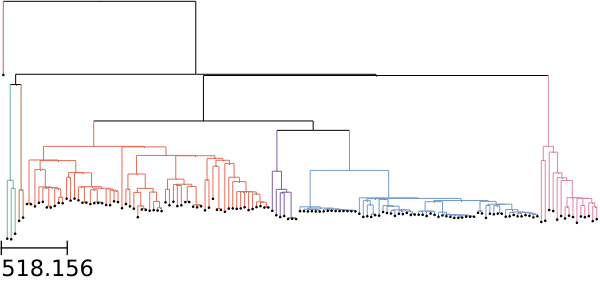

In [110]:
in_Tree = Mtb_151CI_Tree_V1.copy()
in_Tree.render("%%inline", w = 600, tree_style = ts_ColLin)

In [111]:
# in_Tree = Mtb_151CI_Tree_V1.copy()
# in_Tree.render("%%inline", w = 800, tree_style = ts_ColLin_circ)

In [112]:
# in_Tree = Mtb_151CI_Tree_V1.copy()
# in_Tree.render("%%inline", w = 800, tree_style = ts_ColLin_FullCirc)

### Viz `Mtb151CI` Tree - `Custom Matplotlib tree viz Function`

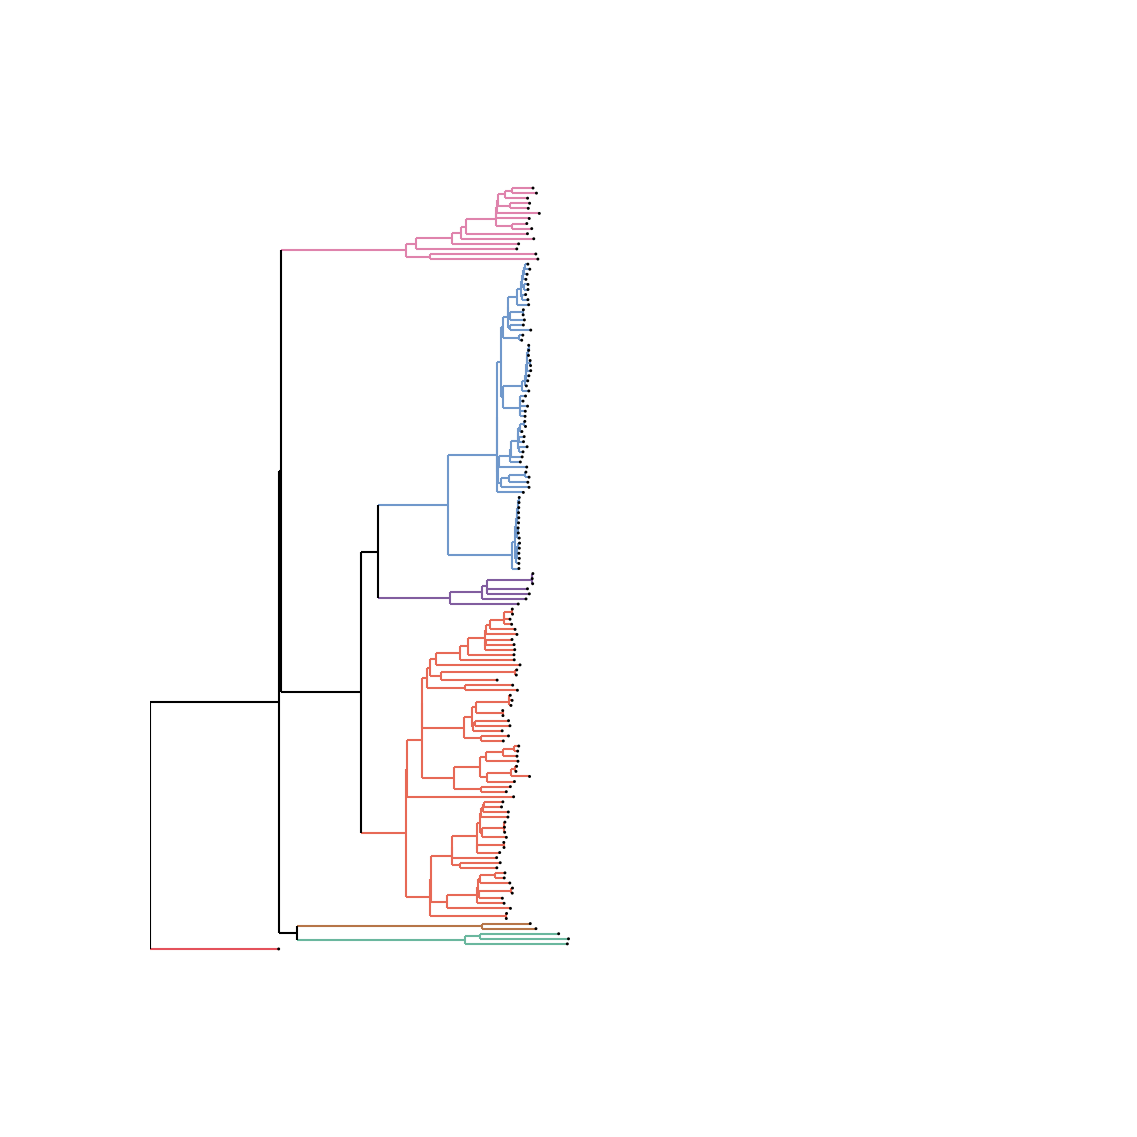

In [113]:
fig, ax_1 = plt.subplots(figsize=(3, 3))

### 1) Plot tree on ax1 axis
coords, NameToCoords = mpl_plot_tree(Mtb_151CI_Tree_V1,
                                     name_offset=0.7,
                                     axe=ax_1,
                                     show_names=False,
                                     draw_leaf_nodes=True,
                                     leaf_node_size=1.0,
                                     pad_right=1,
                                     show_scale_bar = False,
                                     )

#fig

# Classify & Divide sets of GC Events based on Paralog Mapping results

In [114]:
GCE_All_DF = GRE_AnnoByMatch_DF
GCE_ABM_DF = GRE_AnnoByMatch_DF

# Seperate GC Event Info DF into GCEs WITH and WITHOUT paralogs
GCE_InPR_DF = GCE_All_DF.query("NumHmTargets > 0")
GCE_NotInPR_DF = GCE_All_DF.query("NumHmTargets == 0")

mGCE_DF = GRE_AnnoByMatch_DF.query("MappedEvent == True") #.query("Max_KmerMatch_ToHm >= 0.5")
GCE_Mapped_DF = mGCE_DF

GCE_NotMapped_DF = GRE_AnnoByMatch_DF.query("MappedEvent == False") #.query("Max_KmerMatch_ToHm < 0.5")

GCE_NotMapped_InPR_DF = GCE_NotMapped_DF.query("NumHmTargets > 0")

GCE_NotMapped_NotInPR_DF = GCE_NotMapped_DF.query("NumHmTargets == 0")


print("# of TOTAL detected events", GCE_All_DF.shape[0])

print("# of detected events IN a Paralog-Region:", GCE_InPR_DF.shape[0])
print("# of detected events NOT IN a Paralog-Region:", GCE_NotInPR_DF.shape[0])
print("")
print("# of mapped events", GCE_Mapped_DF.shape[0])
print("# of NOT MAPPED events:", GCE_NotMapped_DF.shape[0])

print("# of NOT MAPPED events IN a Paralog-Region:", GCE_NotMapped_InPR_DF.shape[0])
#print("# of NOT MAPPED events NOT IN a Paralog-Region:", GCE_NotMapped_NotInPR_DF.shape[0])


# of TOTAL detected events 324
# of detected events IN a Paralog-Region: 295
# of detected events NOT IN a Paralog-Region: 29

# of mapped events 217
# of NOT MAPPED events: 107
# of NOT MAPPED events IN a Paralog-Region: 78


In [115]:
#GCE_All_DF["Freq_SNP_FoundInAnyPR"].describe()

In [116]:
GCE_All_DF.query("Max_KmerMatch_ToHm >= 0.5").shape

(217, 47)

In [117]:
GCE_All_DF.query("Max_KmerMatch_ToHm > 0.5").shape

(213, 47)

In [118]:
GCE_All_DF.query("Max_KmerMatch_ToHm == 0.5")

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots
99,NC_000962.3,1340667,1341102,.,Node_28,M0016395_7,650.777286,4,[M0016395_7],1340666,1340884.0,436,lineage4,0,"esxK,esxL","Rv1197,Rv1198",Event_100,True,False,False,False,PR_HmRegion_054,4,1,0,0,0,0,1,1,1,True,0.0,4,1,"esxM,esxN-H37Rv-2030331-2030976","esxM,esxN",0.5,689769.5,44,2,"esxI,esxJ-H37Rv-1160545-1161167-esxV,esxW-H37R...","esxI,esxJ-esxV,esxW",0.5000,NaN,True,2
114,NC_000962.3,1633632,1634550,.,Node_50,mada_1-50,178.726517,14,[mada_1-50],1633631,1634090.5,919,lineage4,0,PE_PGRS27,Rv1450c,Event_115,False,True,False,False,PR_HmRegion_064,2,1,0,0,2,1,1,1,1,True,0.0,2,1,"PE_PGRS28,Rv1453-H37Rv-1636705-1638392","PE_PGRS28,Rv1453",0.5,3458.0,68,1,"PE_PGRS28,Rv1453-H37Rv-1636705-1638392","PE_PGRS28,Rv1453",0.3571,3458.0,True,1
197,NC_000962.3,2301782,2302132,.,Node_1,N1272,995.397454,4,[N1272],2301781,2301956.5,351,lineage5,0,pks12,Rv2048c,Event_198,False,False,False,True,PR_HmRegion_099,1,1,0,0,0,0,2,1,1,True,0.0,1,1,pks12-H37Rv-2294816-2298269,pks12,0.5,5414.0,44,1,pks12-H37Rv-2294816-2298269,pks12,0.5000,5414.0,True,0
199,NC_000962.3,2301782,2302132,.,Node_45,Node_37,414.061034,4,"[01_R1430, M0011368_9]",2301781,2301956.5,351,lineage4,2,pks12,Rv2048c,Event_200,False,False,False,True,PR_HmRegion_099,1,1,0,0,0,0,2,1,2,False,0.0,1,1,pks12-H37Rv-2294816-2298269,pks12,0.5,5414.0,44,1,pks12-H37Rv-2294816-2298269,pks12,0.5000,5414.0,True,0


In [119]:
GCE_All_DF.query("Max_KmerMatch_ToHm == 0.5")[["EventID", "Lineage", "Parent_Node", "Child_Node",
                                               "snp_count", "taxa_List", "Overlap_Genes",
                                               "Top_KmerMatch_HomologTarIDs", "Max_KmerMatch_ToHm", "Max_SNPMatch_ToHm", "Top_SNPMatch_HomologTarIDs"]]

,EventID,Lineage,Parent_Node,Child_Node,snp_count,taxa_List,Overlap_Genes,Top_KmerMatch_HomologTarIDs,Max_KmerMatch_ToHm,Max_SNPMatch_ToHm,Top_SNPMatch_HomologTarIDs
99,Event_100,lineage4,Node_28,M0016395_7,4,[M0016395_7],"esxK,esxL","esxM,esxN-H37Rv-2030331-2030976",0.5,0.5000,"esxI,esxJ-H37Rv-1160545-1161167-esxV,esxW-H37R..."
114,Event_115,lineage4,Node_50,mada_1-50,14,[mada_1-50],PE_PGRS27,"PE_PGRS28,Rv1453-H37Rv-1636705-1638392",0.5,0.3571,"PE_PGRS28,Rv1453-H37Rv-1636705-1638392"
197,Event_198,lineage5,Node_1,N1272,4,[N1272],pks12,pks12-H37Rv-2294816-2298269,0.5,0.5000,pks12-H37Rv-2294816-2298269
199,Event_200,lineage4,Node_45,Node_37,4,"[01_R1430, M0011368_9]",pks12,pks12-H37Rv-2294816-2298269,0.5,0.5000,pks12-H37Rv-2294816-2298269


In [120]:
GCE_All_DF.query("Max_KmerMatch_ToHm == 0.5")[["Top_KmerMatch_HomologTarIDs"]].values

array([['esxM,esxN-H37Rv-2030331-2030976'],
       ['PE_PGRS28,Rv1453-H37Rv-1636705-1638392'],
       ['pks12-H37Rv-2294816-2298269'],
       ['pks12-H37Rv-2294816-2298269']], dtype=object)

In [121]:
GCE_All_DF.query("Max_KmerMatch_ToHm == 0.5")[["Top_SNPMatch_HomologTarIDs"]].values

array([['esxI,esxJ-H37Rv-1160545-1161167-esxV,esxW-H37Rv-4059985-4060591'],
       ['PE_PGRS28,Rv1453-H37Rv-1636705-1638392'],
       ['pks12-H37Rv-2294816-2298269'],
       ['pks12-H37Rv-2294816-2298269']], dtype=object)

# Part A: Summarize initial stats of detected GC Events (`GCEs`)

## Q 1.1: What is the general results breakdown of GC detection pipeline?

### How many total putative Gene Conversion events detected across the entire genome? (324 in total)

In [122]:
GRE_ABM_DF.shape

(324, 47)

### How many putative Gene Conversion events detected in PRs (Paralogous Regions)? (`295/324`, `91%`)

In [123]:
GCE_InPR_DF.shape[0]

295

In [124]:
GCE_InPR_DF.shape[0] / GCE_All_DF.shape[0]

0.9104938271604939

In [125]:
295/324

0.9104938271604939

### How many putative Gene Conversion events NOT detected in PRs ? (`29/324`, `9%`)

In [126]:
GRE_ABM_NotInPR_DF = GRE_ABM_DF.query("N_HmMapAln_PR_Ovrlap == 0")
GRE_ABM_NotInPR_DF.shape

(29, 47)

In [127]:
29/324

0.08950617283950617

#### How many detected GCEs were confidently mapped to H37Rv paralog?
(217/324, 67%) <br>
(217/295, 74%)


ie `How many gene conversion events could be confidently resolved with clear donor sequences matching paralogs in the H37Rv reference genome?`

In [128]:
GCE_Mapped_DF.shape

(217, 47)

In [129]:
GCE_Mapped_DF.shape[0] / GCE_All_DF.shape[0]

0.6697530864197531

In [130]:
GCE_Mapped_DF.shape[0] / GCE_InPR_DF.shape[0]

0.735593220338983

In [131]:
GRE_ABM_DF["MappedEvent"].value_counts()

MappedEvent
True     217
False    107
Name: count, dtype: int64

#### How many putative GCEs were NOT mapped to H37Rv paralog? (107, 33%)?

In [132]:
GCE_NotMapped_DF.shape

(107, 47)

In [133]:
GCE_NotMapped_DF.shape[0] / GRE_ABM_DF.shape[0]

0.33024691358024694

In [134]:
GCE_NotMapped_DF.shape[0] / GCE_InPR_DF.shape[0]

0.36271186440677966

### How many putative Gene Conversion events NOT in PRs BUT ARE IN  Locally Repetitive Regions? (`23/29`)

In [135]:
GRE_ABM_NoPR_InLR_DF = GRE_ABM_DF.query("N_HmMapAln_PR_Ovrlap == 0 & (N_HmMapAln_LR_Ovrlap > 0 | N_LCR_Ovrlap > 0 | N_LowPmap_Ovrlap > 0) ")  
GRE_ABM_NoPR_InLR_DF.shape

(23, 47)

### How many putative Gene Conversion events NOT in PRs and not in Locally Repetitive Regions? (`6/29`)

In [136]:
GRE_ABM_NoPR_NoLR_NoLowPmap_DF  = GRE_ABM_DF.query("N_HmMapAln_PR_Ovrlap == 0 & N_HmMapAln_LR_Ovrlap == 0 & N_LCR_Ovrlap == 0 & N_LowPmap_Ovrlap == 0 ")
GRE_ABM_NoPR_NoLR_NoLowPmap_DF.shape


(6, 47)

In [137]:
GRE_ABM_NoPR_NoLR_NoLowPmap_DF["Overlap_Genes"].value_counts()

Overlap_Genes
Rv2082       5
PE_PGRS58    1
Name: count, dtype: int64

In [138]:
GRE_ABM_NoPR_NoLR_NoLowPmap_DF

,seqname,start_1based,end_1based,strand,Parent_Node,Child_Node,neg_log_likelihood,snp_count,taxa_List,start_0based,CenterOfRegion,EventLen,Lineage,Num_Tips_Downstream,Overlap_Genes,Overlap_Gene_RvIDs,EventID,Contains_Esx,Contains_PEPPE,Contains_REP13E12,NoOverlap_Wi_PEPPE_Esx_13E12_Genes,Overlap_HHRs,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMap_ParalogReg,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMap_LocalRepeat,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmapRegion,LenOfTaxaList,IsTermNode,Freq_SNP_FoundInAnyPR,NumHmTargets,NumHm_AtMaxKmerMatch,Top_KmerMatch_HomologTarIDs,Top_KmerMatch_HomologGeneIDs,Max_KmerMatch_ToHm,DistToHm_TopKmatch,TotalKmers_Eval,NumHm_AtMaxSNPMatch,Top_SNPMatch_HomologTarIDs,Top_SNPMatch_HomologGeneIDs,Max_SNPMatch_ToHm,DistToHm_TopSNPmatch,MappedEvent,N_NucDivHotSpots
200,NC_000962.3,2338768,2338994,.,Node_149,RW-TB008,4468.693807,7,[RW-TB008],2338767,2338880.5,227,lineage8,0,Rv2082,Rv2082,Event_201,False,False,False,True,NaN,0,0,0,0,0,0,0,0,1,True,0.0,0,0,NaN,NaN,0.0,NaN,0,0,NaN,NaN,NaN,NaN,False,1
201,NC_000962.3,2338768,2338994,.,Node_25,Node_24,708.633695,7,"[S0106-01, R21770, R21839, R21363, mada_1-32, ...",2338767,2338880.5,227,lineage4,7,Rv2082,Rv2082,Event_202,False,False,False,True,NaN,0,0,0,0,0,0,0,0,7,False,0.0,0,0,NaN,NaN,0.0,NaN,0,0,NaN,NaN,NaN,NaN,False,1
202,NC_000962.3,2338768,2338994,.,Node_64,TB3251,2039.370216,6,[TB3251],2338767,2338880.5,227,lineage4,0,Rv2082,Rv2082,Event_203,False,False,False,True,NaN,0,0,0,0,0,0,0,0,1,True,0.0,0,0,NaN,NaN,0.0,NaN,0,0,NaN,NaN,NaN,NaN,False,1
203,NC_000962.3,2338773,2338994,.,Node_4,Node_1,3434.617912,6,"[N1272, N1176]",2338772,2338883.0,222,lineage5,2,Rv2082,Rv2082,Event_204,False,False,False,True,NaN,0,0,0,0,0,0,0,0,2,False,0.0,0,0,NaN,NaN,0.0,NaN,0,0,NaN,NaN,NaN,NaN,False,1
204,NC_000962.3,2339719,2339726,.,Node_148,Node_133,1650.581593,4,"[mada_2-31, mada_1-41, MT_0080, mada_102, TB33...",2339718,2339722.0,8,NaN,130,Rv2082,Rv2082,Event_205,False,False,False,True,NaN,0,0,0,0,0,0,0,0,130,False,0.0,0,0,NaN,NaN,0.0,NaN,0,0,NaN,NaN,NaN,NaN,False,1
320,NC_000962.3,4032911,4032977,.,Node_149,RW-TB008,4738.701772,13,[RW-TB008],4032910,4032943.5,67,lineage8,0,PE_PGRS58,Rv3590c,Event_321,False,True,False,False,NaN,0,0,0,0,0,0,0,0,1,True,0.0,0,0,NaN,NaN,0.0,NaN,0,0,NaN,NaN,NaN,NaN,False,0


# Part 2: Analysis of overlap between GC events & NucDiv hotspots

Key questions are:
- What % of GC events overlap with an initially identified NucDiv hotspot?
- What % of NucDiv hotspots contained a GC event?

### Create a 1-kb window summary of NucDiv, mGC + pGC event counts, and HHR overlap

In [139]:
RE_CoordCols = ("seqname", "start_0based", "end_1based")
GenomeAnno_CoordCols = ("Chrom", "Start", "End")
Hm_Query_CoordCols = ("Query_Name", "Query_Start", "Query_End")
Hm_Target_CoordCols = ("Target_Name", "Target_Start", "Target_End")
NucDiv_CoordCols = ("Chrom", "Start", "End")

NucDiv_WiGCECt_DF = bf.count_overlaps(WGA_NucDiv_PI_1kb_DF,
                                      GCE_Mapped_DF,
                                      cols1 = ("Chrom", "Start", "End"),
                                      cols2 = RE_CoordCols).rename(columns={'count': 'N_mGCE'})

NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                      GRE_ABM_DF,
                                      cols1 = ("Chrom", "Start", "End"),
                                      cols2 = RE_CoordCols).rename(columns={'count': 'N_pGCE'})

NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                          HmMap_Aln_k19w19_NoOverlap_DF, 
                                          cols1 = NucDiv_CoordCols,
                                          cols2 = Hm_Target_CoordCols ).rename(columns={'count': 'N_Ovrlap_ParalogAlns'})

#### Add counts of (TOTAL Paralog-SNPs per HmRegion)

NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                              Mtb_HM_Var_PR_SNPs_DF,
                                              cols1 = ("Chrom", "Start", "End"),
                                              cols2 = Hm_Target_CoordCols).rename(columns={'count': 'Num_PR_SNPs_All'})

#### Add counts of UNIQUE PR-SNPs per HmRegion
NucDiv_WiGCECt_DF = bf.count_overlaps(NucDiv_WiGCECt_DF,
                                      Mtb_HM_Var_PR_SNPs_Trim_TrimUnq_DF,
                                      cols1 = ("Chrom", "Start", "End"),
                                      cols2 = Hm_Target_CoordCols).rename(columns={'count': 'Num_PR_SNPs_Unq'})

NucDiv_WiGCECt_DF.shape


(4421, 25)

### Peak at the combined NucDiv and GCE DF (per 1kb window)

In [142]:
NucDiv_WiGCECt_DF.head()

,Chrom,Start,End,NucDiv,OverlapGenes,Middle,NucDiv_kb,NucDiv_Z,NucDiv_ModZ,IsNucDivHotspot,N_HmMapAln_PR_Ovrlap,OvrlapWi_HmMapAln_PR,N_HmMapAln_LR_Ovrlap,OvrlapWi_HmMapAln_LR,N_LCR_Ovrlap,OvrlapWi_LowComplexityRegion,N_LowPmap_Ovrlap,OvrlapWi_LowPmap,PLC_Mask_Count,PLC_Mask_Ovrlap,N_mGCE,N_pGCE,N_Ovrlap_ParalogAlns,Num_PR_SNPs_All,Num_PR_SNPs_Unq
0,NC_000962.3,0,1000,0.000218,dnaA,500.0,0.217905,-0.178778,0.127863,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,NC_000962.3,1000,2000,0.000791,dnaA,1500.0,0.790654,0.829172,2.920256,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,NC_000962.3,2000,3000,0.000306,dnaN,2500.0,0.305560,-0.024519,0.555218,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,NC_000962.3,3000,4000,0.000221,"dnaN,recF",3500.0,0.221073,-0.173203,0.143308,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,NC_000962.3,4000,5000,0.000222,"recF,Rv0004",4500.0,0.222481,-0.170725,0.150173,False,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [143]:
NucDiv_WiGCECt_DF.columns

Index(['Chrom', 'Start', 'End', 'NucDiv', 'OverlapGenes', 'Middle', 'NucDiv_kb', 'NucDiv_Z', 'NucDiv_ModZ', 'IsNucDivHotspot', 'N_HmMapAln_PR_Ovrlap', 'OvrlapWi_HmMapAln_PR', 'N_HmMapAln_LR_Ovrlap', 'OvrlapWi_HmMapAln_LR', 'N_LCR_Ovrlap', 'OvrlapWi_LowComplexityRegion', 'N_LowPmap_Ovrlap', 'OvrlapWi_LowPmap', 'PLC_Mask_Count', 'PLC_Mask_Ovrlap', 'N_mGCE', 'N_pGCE', 'N_Ovrlap_ParalogAlns', 'Num_PR_SNPs_All', 'Num_PR_SNPs_Unq'], dtype='object')

### Q 2.1: What % of GCEs overlap with an initially identified NucDiv hotspot? (208/324, 64%)

In [293]:
GCE_All_DF.query("N_NucDivHotSpots > 0").shape[0]

208

In [294]:
GCE_All_DF.shape[0]

324

In [295]:
GCE_All_DF.query("N_NucDivHotSpots > 0").shape[0] / GCE_All_DF.shape[0]

0.6419753086419753

In [1]:
208 / 324

0.6419753086419753

### Q 2.2: What % of NucDiv hotspots overlap with at least 1 DETECTED GC event? (33/37, 89%)

In [296]:
NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True & N_pGCE > 0").shape

(33, 25)

In [297]:
NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True & N_pGCE > 0").shape[0] / NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True").shape[0]   

0.8918918918918919

### Q 2.3: What % of NucDiv hotspots overlap with at least 1 MAPPED GC event? (28/37, 76%)

In [298]:
NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True & N_mGCE > 0").shape   

(28, 25)

In [299]:
NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True & N_mGCE > 0").shape[0] / NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True").shape[0]   

0.7567567567567568

In [300]:
#NucDiv_WiGCECt_DF.query("IsNucDivHotspot == True & N_mGCE == 0")

# Part 3: Look at correlation of NucDiv & mGCE across Mtb genome

### Viz relationship between NucDiv & pGCE frequency (ALL 1-kb windows)

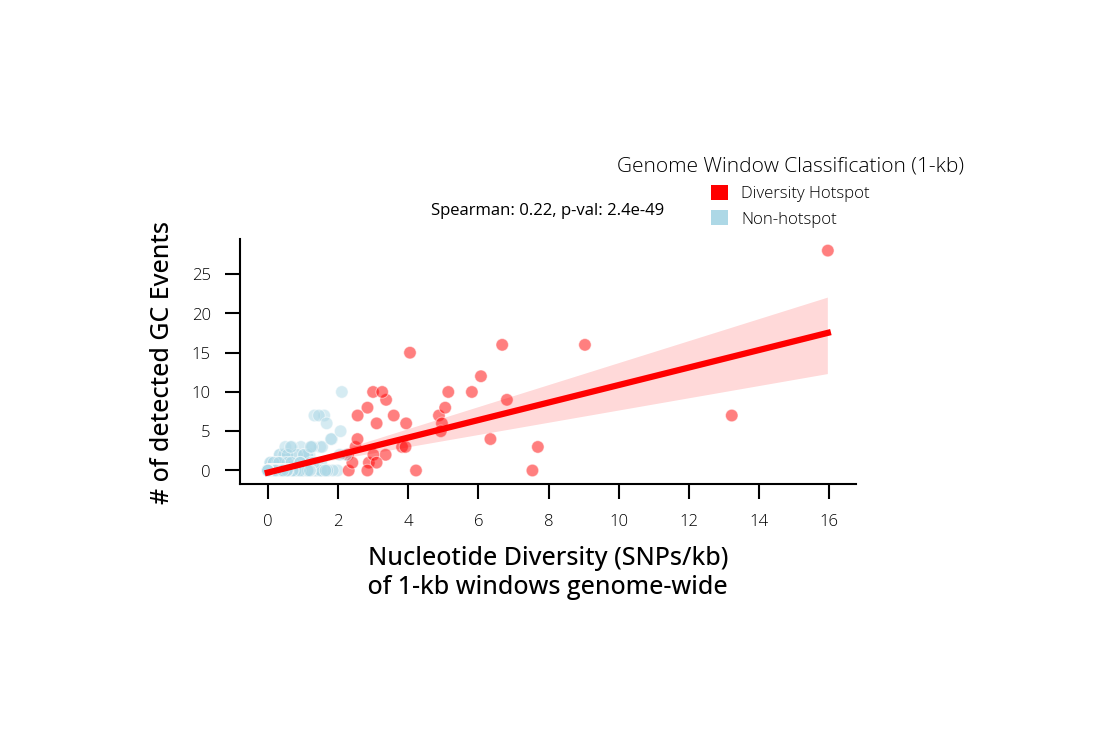

In [301]:

# Define a custom color palette
Hotspot_Palette = {True: 'red', False: 'lightblue'}
custom_labels = {True: "Diversity Hotspot", False: "Non-hotspot"}

# Filter the DataFrame for plotting
In_DF = NucDiv_WiGCECt_DF #.query("N_Ovrlap_ParalogAlns > 0")

# Calculate Spearman correlation coefficients
spearman_corr, spearman_p_value = stats.spearmanr(In_DF['NucDiv_kb'], In_DF['N_pGCE'])

# Create a figure with subplots
fig, axes = plt.subplots(1, 1, figsize=(3, 2))

# Plot 1: Dist vs EventsMapped
sns.scatterplot(x='NucDiv_kb', y='N_pGCE', hue = "IsNucDivHotspot", data=In_DF, 
                palette = Hotspot_Palette, alpha=0.5, ax=axes)

sns.regplot(x='NucDiv_kb', y='N_pGCE', data=In_DF, scatter=False, color='red', ax=axes)
axes.ticklabel_format(style='plain', axis='y')

axes.set_title(f'Spearman: {spearman_corr:.2f}, p-val: {spearman_p_value:.2g}', fontsize=4)

axes.set_xlabel("Nucleotide Diversity (SNPs/kb)\n of 1-kb windows genome-wide ", fontsize=6)

axes.set_ylabel("# of detected GC Events", fontsize=6)

axes.tick_params(axis='both', which='major', labelsize=4)

# Create a custom legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=color, label=custom_labels[key]) for key, color in Hotspot_Palette.items()]
legend = axes.legend(handles=legend_handles, title="Genome Window Classification (1-kb)", 
                     loc='upper right', bbox_to_anchor=(1.2, 1.4), fontsize=4, title_fontsize=5, ) # frameon=False

sns.despine(ax=axes)
plt.show()


### Viz relationship between NucDiv & pGCE frequency (1-kb windows in HHRs)

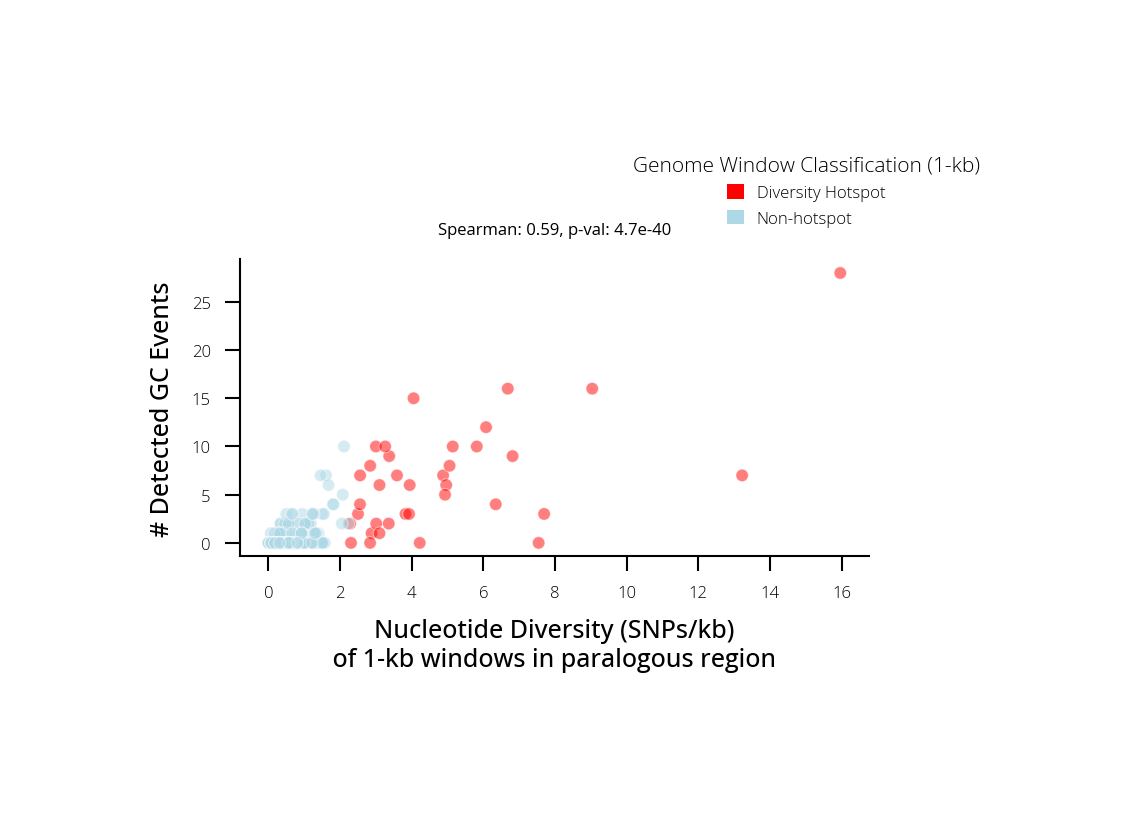

In [358]:

# Define a custom color palette
Hotspot_Palette = {True: 'red', False: 'lightblue'}
custom_labels = {True: "Diversity Hotspot", False: "Non-hotspot"}

# Filter the DataFrame for plotting
In_DF = NucDiv_WiGCECt_DF.query("N_Ovrlap_ParalogAlns > 0")

# Calculate Spearman correlation coefficients
spearman_corr, spearman_p_value = stats.spearmanr(In_DF['NucDiv_kb'], In_DF['N_pGCE'])

# Create a figure with subplots
fig, axes = plt.subplots(1, 1, figsize=(3, 2))

# Plot 1: Dist vs EventsMapped
sns.scatterplot(x='NucDiv_kb', y='N_pGCE', hue = "IsNucDivHotspot", data=In_DF, 
                palette = Hotspot_Palette, alpha=0.5, ax=axes)

# sns.regplot(x='NucDiv_kb', y='N_pGCE', data=In_DF, scatter=False, color='red', ax=axes)
axes.ticklabel_format(style='plain', axis='y')

axes.set_title(f'Spearman: {spearman_corr:.2f}, p-val: {spearman_p_value:.2g}', fontsize=4)

axes.set_xlabel("Nucleotide Diversity (SNPs/kb)\n of 1-kb windows in paralogous region ", fontsize=6)

axes.set_ylabel("# Detected GC Events", fontsize=6)

axes.tick_params(axis='both', which='major', labelsize=4)

# Create a custom legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=color, label=custom_labels[key]) for key, color in Hotspot_Palette.items()]
legend = axes.legend(handles=legend_handles, title="Genome Window Classification (1-kb)", 
                     loc='upper right', bbox_to_anchor=(1.2, 1.4), fontsize=4, title_fontsize=5, ) # frameon=False

sns.despine(ax=axes)

fig.savefig("./Fig3.GCE_Results/PerPR.NucDivVsGCEFreq.v1.svg")
fig.savefig("./Fig3.GCE_Results/PerPR.NucDivVsGCEFreq.v1.png", dpi = 300)

plt.show()


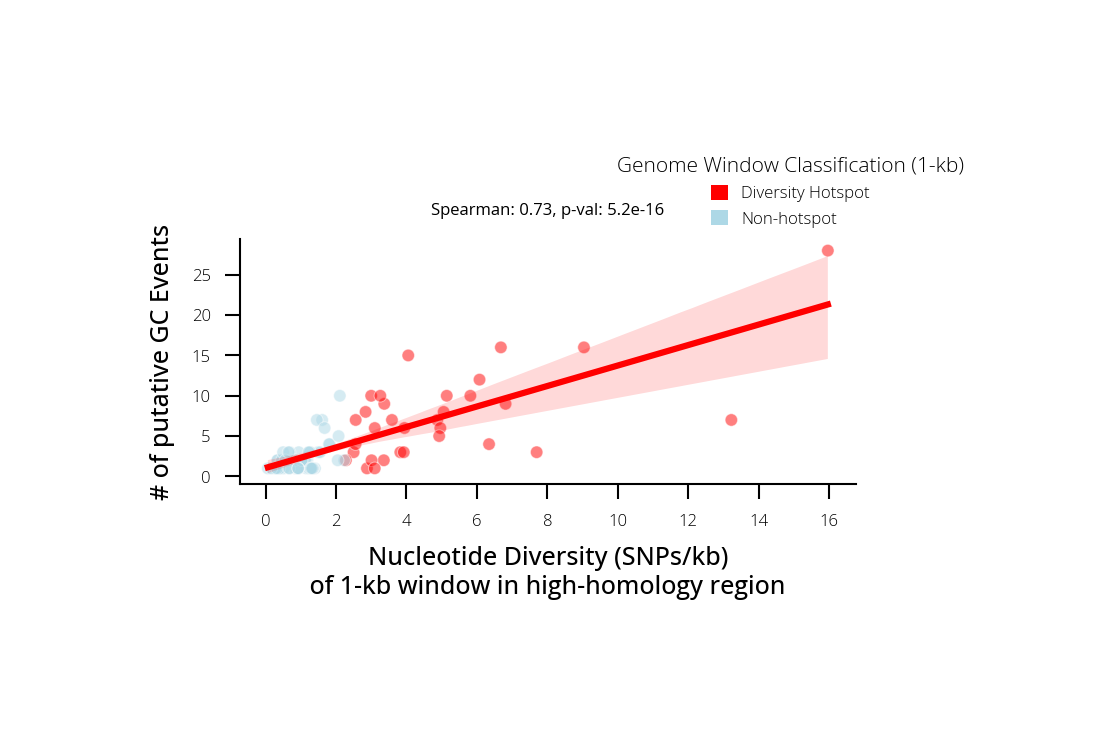

In [303]:

# Define a custom color palette
Hotspot_Palette = {True: 'red', False: 'lightblue'}
custom_labels = {True: "Diversity Hotspot", False: "Non-hotspot"}

# Filter the DataFrame for plotting
In_DF = NucDiv_WiGCECt_DF.query("N_Ovrlap_ParalogAlns > 0 & N_pGCE > 0")

# Calculate Spearman correlation coefficients
spearman_corr, spearman_p_value = stats.spearmanr(In_DF['NucDiv_kb'], In_DF['N_pGCE'])

# Create a figure with subplots
fig, axes = plt.subplots(1, 1, figsize=(3, 2))

# Plot 1: Dist vs EventsMapped
sns.scatterplot(x='NucDiv_kb', y='N_pGCE', hue = "IsNucDivHotspot", data=In_DF, 
                palette = Hotspot_Palette, alpha=0.5, ax=axes)

sns.regplot(x='NucDiv_kb', y='N_pGCE', data=In_DF, scatter=False, color='red', ax=axes)
axes.ticklabel_format(style='plain', axis='y')

axes.set_title(f'Spearman: {spearman_corr:.2f}, p-val: {spearman_p_value:.2g}', fontsize=4)

axes.set_xlabel("Nucleotide Diversity (SNPs/kb)\n of 1-kb window in high-homology region ", fontsize=6)

axes.set_ylabel("# of putative GC Events", fontsize=6)

axes.tick_params(axis='both', which='major', labelsize=4)

# Create a custom legend
from matplotlib.patches import Patch
legend_handles = [Patch(color=color, label=custom_labels[key]) for key, color in Hotspot_Palette.items()]
legend = axes.legend(handles=legend_handles, title="Genome Window Classification (1-kb)", 
                     loc='upper right', bbox_to_anchor=(1.2, 1.4), fontsize=4, title_fontsize=5, ) # frameon=False

sns.despine(ax=axes)
plt.show()


# Part 4: Analyze gene categories associated w/ mGC events 
- What is the breakdown of gene categories overlapping w/ recomb events?
- How many unique genes within each category are found to have mapped GC events?

### Part 5.1 - Count Mapped-GC events per Gene in the Mtb genome

In [304]:
GCE_CtPerGene_DF.shape

(4079, 15)

In [305]:
GCE_CtPerGene_Atleast1_DF.shape

(76, 15)

In [306]:
GCE_CountByGene_DF = GCE_CtPerGene_DF

In [307]:
GCE_CountByGene_DF.head(2)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,pGCE_Count,CenterOfRegion
0,NC_000962.3,0,1524,+,Rv0001,dnaA,CDS,information pathways,No,Chromosomal replication initiator protein DnaA,NaN,NotExcluded,information pathways,0,762.0
1,NC_000962.3,2051,3260,+,Rv0002,dnaN,CDS,information pathways,No,DNA polymerase III (beta chain) DnaN (DNA nucl...,NaN,NotExcluded,information pathways,0,2655.5


In [308]:
GCE_CtPerGene_Atleast1_DF["Symbol"].nunique()

76

In [309]:
#GCE_CtPerGene_Atleast1_DF["Symbol"].value_counts()

### Part 5.2 - Subset for gene info of genes overlapping with detected GC Events

In [310]:
GCE_CtPerGene_Atleast1_DF.head(3)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,pGCE_Count,CenterOfRegion
98,NC_000962.3,102814,103663,-,Rv0093c,Rv0093c,CDS,cell wall and cell processes,No,Probable conserved membrane protein,NaN,NotExcluded,cell wall and cell processes,1,103238.5
99,NC_000962.3,103709,104663,-,Rv0094c,Rv0094c,CDS,insertion seqs and phages,No,Conserved hypothetical protein,NaN,InsertionSeqs_And_Phages,REP13E12_Repeat,17,104186.0
100,NC_000962.3,104804,105215,-,Rv0095c,Rv0095c,CDS,insertion seqs and phages,No,Conserved hypothetical protein,NaN,InsertionSeqs_And_Phages,REP13E12_Repeat,18,105009.5


In [311]:

GeneIDs_WiAnyGCE = GCE_CtPerGene_Atleast1_DF["Symbol"].values
print("# of GeneIDs overlapping w/ ANY GCE:", len(GeneIDs_WiAnyGCE))


# of GeneIDs overlapping w/ ANY GCE: 76


In [312]:
GeneAnnoInfo_OvrlapWiAnyGCE = H37Rv_GenomeAnno_Genes_DF[H37Rv_GenomeAnno_Genes_DF["Symbol"].isin(GeneIDs_WiAnyGCE)]
GeneAnnoInfo_OvrlapWiAnyGCE.shape

(76, 13)

In [313]:
GeneAnnoInfo_OvrlapWiAnyGCE.shape

(76, 13)

In [314]:
GCE_CtPerGene_Atleast1_DF.shape

(76, 15)

In [315]:
GCE_CtPerGene_Atleast1_DF.head(3)

,Chrom,Start,End,Strand,H37rv_GeneID,Symbol,Feature,Functional_Category,Is_Pseudogene,Product,PEandPPE_Subfamily,ExcludedGroup_Category,Gene_Cat_V2,pGCE_Count,CenterOfRegion
98,NC_000962.3,102814,103663,-,Rv0093c,Rv0093c,CDS,cell wall and cell processes,No,Probable conserved membrane protein,NaN,NotExcluded,cell wall and cell processes,1,103238.5
99,NC_000962.3,103709,104663,-,Rv0094c,Rv0094c,CDS,insertion seqs and phages,No,Conserved hypothetical protein,NaN,InsertionSeqs_And_Phages,REP13E12_Repeat,17,104186.0
100,NC_000962.3,104804,105215,-,Rv0095c,Rv0095c,CDS,insertion seqs and phages,No,Conserved hypothetical protein,NaN,InsertionSeqs_And_Phages,REP13E12_Repeat,18,105009.5


## Part 5.3 - Process gene functional categories associated w/ mGCE events

In [316]:
# Sub_DF = GCE_CtPerGene_Atleast1_DF.query("pGCE_Count > 0")

# Total_DF = H37Rv_GenomeAnno_Genes_DF

column = "Gene_Cat_V2"

all_categories = [ "PE/PPE", "REP13E12_Repeat", "esx",
                  "conserved hypotheticals", "cell wall and cell processes",
                  "insertion seqs and phages",
                  "intermediary metabolism and respiration", "lipid metabolism", "information pathways",
                  "virulence, detoxification, adaptation", "regulatory proteins",
                   "stable RNAs",  "unknown",  ] 

NQ_Colors = ['065275', '029099', '7CCBA1', 'FDDE9C', 'F0746E', 'DC3978', '7C1E6F']


### Get the number of genes per gene category across entire H37Rv genome

In [317]:

AllGenes_category_counts = H37Rv_GenomeAnno_Genes_DF[column].value_counts().reindex(all_categories, fill_value=0)
AllGenes_category_counts.name = "N_TotalGenes_InRv"

In [318]:
AllGenes_category_counts

Gene_Cat_V2
PE/PPE                                      168
REP13E12_Repeat                              14
esx                                          23
conserved hypotheticals                    1042
cell wall and cell processes                749
insertion seqs and phages                   133
intermediary metabolism and respiration     936
lipid metabolism                            272
information pathways                        242
virulence, detoxification, adaptation       239
regulatory proteins                         198
stable RNAs                                  48
unknown                                      15
Name: N_TotalGenes_InRv, dtype: int64

### Count number of genes per gene category w/ mapped GC event

In [319]:
# Reindex to include all categories with 0 count for missing ones
Genes_With_GCE_GeneCategory_counts      = GeneAnnoInfo_OvrlapWiAnyGCE[column].value_counts().reindex(all_categories, fill_value=0)
Genes_With_GCE_GeneCategory_counts.name = "N_Genes_WiGCE"

Genes_With_GCE_GeneCategory_counts_norm      = GeneAnnoInfo_OvrlapWiAnyGCE[column].value_counts(normalize=True).reindex(all_categories, fill_value=0)
Genes_With_GCE_GeneCategory_counts_norm.name = "N_Genes_WiGCE_Norm"

In [320]:
Genes_With_GCE_GeneCategory_counts.sum()

76

In [321]:
Genes_With_GCE_GeneCategory_counts

Gene_Cat_V2
PE/PPE                                     36
REP13E12_Repeat                            10
esx                                         7
conserved hypotheticals                     7
cell wall and cell processes                3
insertion seqs and phages                   5
intermediary metabolism and respiration     1
lipid metabolism                            3
information pathways                        0
virulence, detoxification, adaptation       3
regulatory proteins                         0
stable RNAs                                 0
unknown                                     1
Name: N_Genes_WiGCE, dtype: int64

In [322]:
Genes_With_GCE_GeneCategory_counts_norm.sum()

1.0

In [323]:
Genes_With_GCE_GeneCategory_counts_norm

Gene_Cat_V2
PE/PPE                                     0.473684
REP13E12_Repeat                            0.131579
esx                                        0.092105
conserved hypotheticals                    0.092105
cell wall and cell processes               0.039474
insertion seqs and phages                  0.065789
intermediary metabolism and respiration    0.013158
lipid metabolism                           0.039474
information pathways                       0.000000
virulence, detoxification, adaptation      0.039474
regulatory proteins                        0.000000
stable RNAs                                0.000000
unknown                                    0.013158
Name: N_Genes_WiGCE_Norm, dtype: float64

In [324]:
AllGenes_category_counts.sum()

4079

### Count number of GCE events per gene category

In [325]:
# Calculate the total number of events for each category in Sub_DF
N_GCE_Events_By_GeneCategory = GCE_CtPerGene_Atleast1_DF.groupby("Gene_Cat_V2")["pGCE_Count"].sum().reindex(all_categories, fill_value=0)
N_GCE_Events_By_GeneCategory.name = "N_GCE"

In [326]:
N_GCE_Events_By_GeneCategory

Gene_Cat_V2
PE/PPE                                     169
REP13E12_Repeat                             87
esx                                         36
conserved hypotheticals                     19
cell wall and cell processes                 6
insertion seqs and phages                    7
intermediary metabolism and respiration      1
lipid metabolism                            10
information pathways                         0
virulence, detoxification, adaptation        5
regulatory proteins                          0
stable RNAs                                  0
unknown                                      3
Name: N_GCE, dtype: int64

In [327]:
Genes_With_GCE_GeneCategory_counts

Gene_Cat_V2
PE/PPE                                     36
REP13E12_Repeat                            10
esx                                         7
conserved hypotheticals                     7
cell wall and cell processes                3
insertion seqs and phages                   5
intermediary metabolism and respiration     1
lipid metabolism                            3
information pathways                        0
virulence, detoxification, adaptation       3
regulatory proteins                         0
stable RNAs                                 0
unknown                                     1
Name: N_Genes_WiGCE, dtype: int64

## Part 5.4 Plot frequency of gene categories of UNIQUE genes w/ GCEs

/tmp/ipykernel_409800/453428574.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=5)  # Adjust 'fontsize' as needed


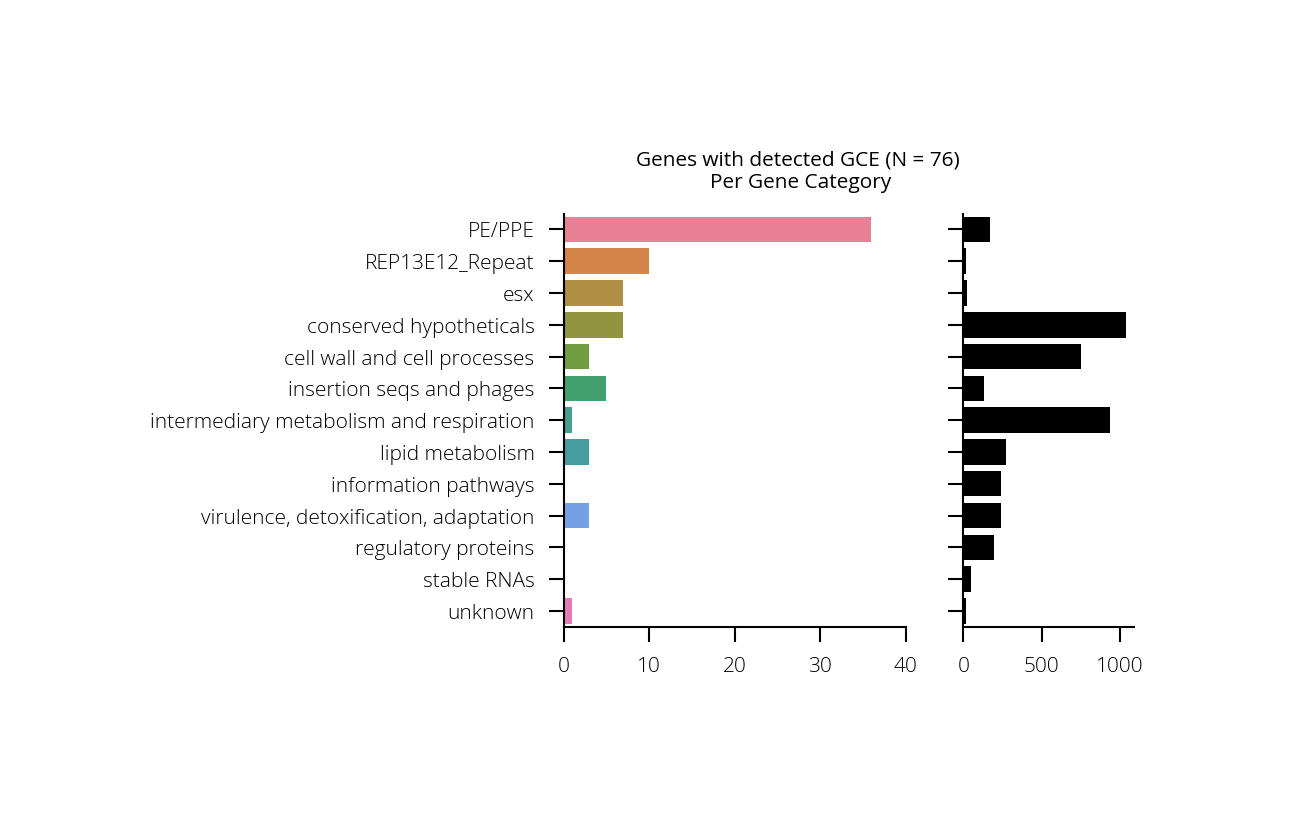

In [328]:
# Create a new figure with 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(3.5, 2),
                               gridspec_kw={'width_ratios': [2, 1]},
                               sharey=False)

# Plot 1
# sns.barplot(y=Genes_With_GCE_GeneCategory_counts.index,
#             x=1, ax = ax1, color="lightgrey")

sns.barplot(y=Genes_With_GCE_GeneCategory_counts.index,
            x=Genes_With_GCE_GeneCategory_counts,
            ax = ax1, hue = Genes_With_GCE_GeneCategory_counts.index)

ax1.set_xticks([0, 10, 20, 30, 40])

# Plot 2
sns.barplot(y=AllGenes_category_counts.index,
            x=AllGenes_category_counts, ax = ax2, color = "black")

ax2.set_xticks([0, 500, 1000])

ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=5)  # Adjust 'fontsize' as needed
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=5)  # Adjust 'fontsize' as needed
ax2.set_xticklabels(ax2.get_xticklabels(), fontsize=5)  # Adjust 'fontsize' as needed
ax2.set_yticklabels([])  # Adjust 'fontsize' as needed
ax1.set_ylabel('')
ax1.set_xlabel('')
ax2.set_xlabel('')
ax2.set_ylabel('')
sns.despine()
fig.suptitle("Genes with detected GCE (N = 76) \nPer Gene Category", 
             x = 0.65, y=0.93, fontsize=5)

plt.show()

#fig.savefig('GenesEffectedByGC.N55.GeneCategoryBreakdown.V1.pdf')


## Part 5.5 - Plot number of GCEs in gene categories

/tmp/ipykernel_409800/3861552974.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=5)  # Adjust 'fontsize' as needed
/tmp/ipykernel_409800/3861552974.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=5)  # Adjust 'fontsize' as needed


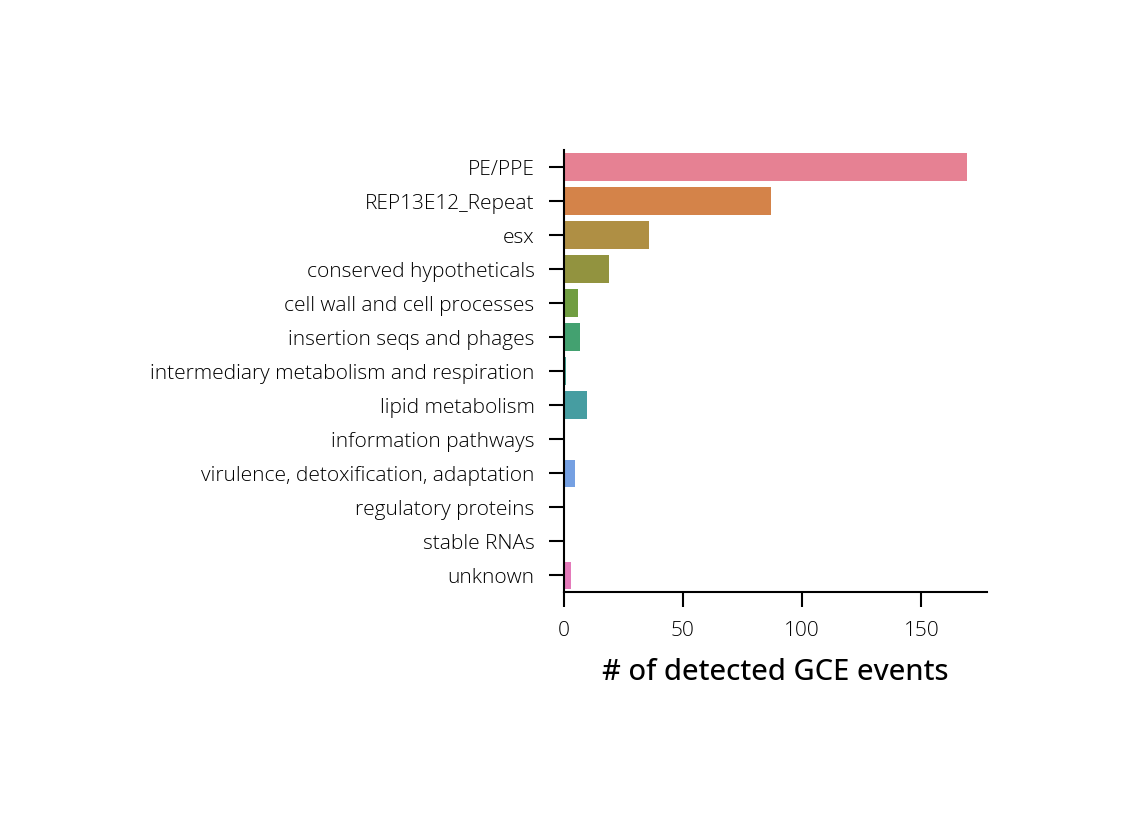

In [329]:
fig, ax1 = plt.subplots(1, 1, figsize=(3, 2))

sns.barplot(y = N_GCE_Events_By_GeneCategory.index,
            x = N_GCE_Events_By_GeneCategory,
            ax = ax1, hue = N_GCE_Events_By_GeneCategory.index)

ax1.set_yticklabels(ax1.get_yticklabels(), fontsize=5)  # Adjust 'fontsize' as needed
ax1.set_xticklabels(ax1.get_xticklabels(), fontsize=5)  # Adjust 'fontsize' as needed
ax1.set_ylabel('')
ax1.set_xlabel('# of detected GCE events')
sns.despine()
# fig.suptitle("Total Detected Gene Conversion Events (N = 324) \nPer Gene Category",
#              x = 0.65, y=0.9, fontsize=5)
plt.show()

#fig.savefig('MappedGCEvents.N213.GeneCategoryBreakdown.V1.pdf')


## Part 5.6 - Summary table of GCEs per gene categories

In [330]:
GeneCategory_GCE_Freq_Summ_DF = pd.concat([N_GCE_Events_By_GeneCategory,
                                  Genes_With_GCE_GeneCategory_counts,
                                  AllGenes_category_counts], axis =1 )

GeneCategory_GCE_Freq_Summ_DF = GeneCategory_GCE_Freq_Summ_DF.reset_index()

GeneCategory_GCE_Freq_Summ_DF.columns = ["Gene_Category",
                                         "Number_GCEs",
                                         "Number_Genes_WiGCE",
                                         "Total_Genes_InH37Rv" ]

GeneCategory_GCE_Freq_Summ_DF = GeneCategory_GCE_Freq_Summ_DF.sort_values("Number_GCEs", ascending=False)


In [331]:
GeneCategory_GCE_Freq_Summ_DF

,Gene_Category,Number_GCEs,Number_Genes_WiGCE,Total_Genes_InH37Rv
0,PE/PPE,169,36,168
1,REP13E12_Repeat,87,10,14
2,esx,36,7,23
3,conserved hypotheticals,19,7,1042
7,lipid metabolism,10,3,272
5,insertion seqs and phages,7,5,133
4,cell wall and cell processes,6,3,749
9,"virulence, detoxification, adaptation",5,3,239
12,unknown,3,1,15
6,intermediary metabolism and respiration,1,1,936


# Part 3: Evaluate distribution of mGCE length & # of SNPs (median: 101 bp, 6 SNPs transfered)

### Q3.1: What is the length and SNP count distribution of mapped GC events? (101 bp, 6 SNPs)

In [332]:
GCE_All_DF[["EventLen", "snp_count"]].describe()

,EventLen,snp_count
count,324.000000,324.000000
mean,191.666667,9.000000
std,243.724455,6.909409
min,4.000000,4.000000
25%,32.750000,5.000000
50%,100.500000,6.000000
75%,244.250000,10.000000
max,1456.000000,47.000000


### Q3.2: How many of the SNPs in a mGCE match a SNP difference found in a paralog (PR)?

In [333]:
GCE_All_DF[["EventLen", "snp_count"]].describe()

,EventLen,snp_count
count,324.000000,324.000000
mean,191.666667,9.000000
std,243.724455,6.909409
min,4.000000,4.000000
25%,32.750000,5.000000
50%,100.500000,6.000000
75%,244.250000,10.000000
max,1456.000000,47.000000



The median putative mGCE tract has a length of 101 bp (IQR: 33–244 bp) and contained 6 SNPs (IQR: 5-10). 

The median mapped mGCE tract has a length of 115 bp (IQR: 38–247 bp) and contained 7 SNPs (IQR: 5-13). 



In [334]:
GCE_All_DF.shape

(324, 47)

In [335]:
!mkdir ./GCE_Length_SNP_Dist_QC

mkdir: cannot create directory ‘./GCE_Length_SNP_Dist_QC’: File exists


### Plot length distr of putative events - histograms

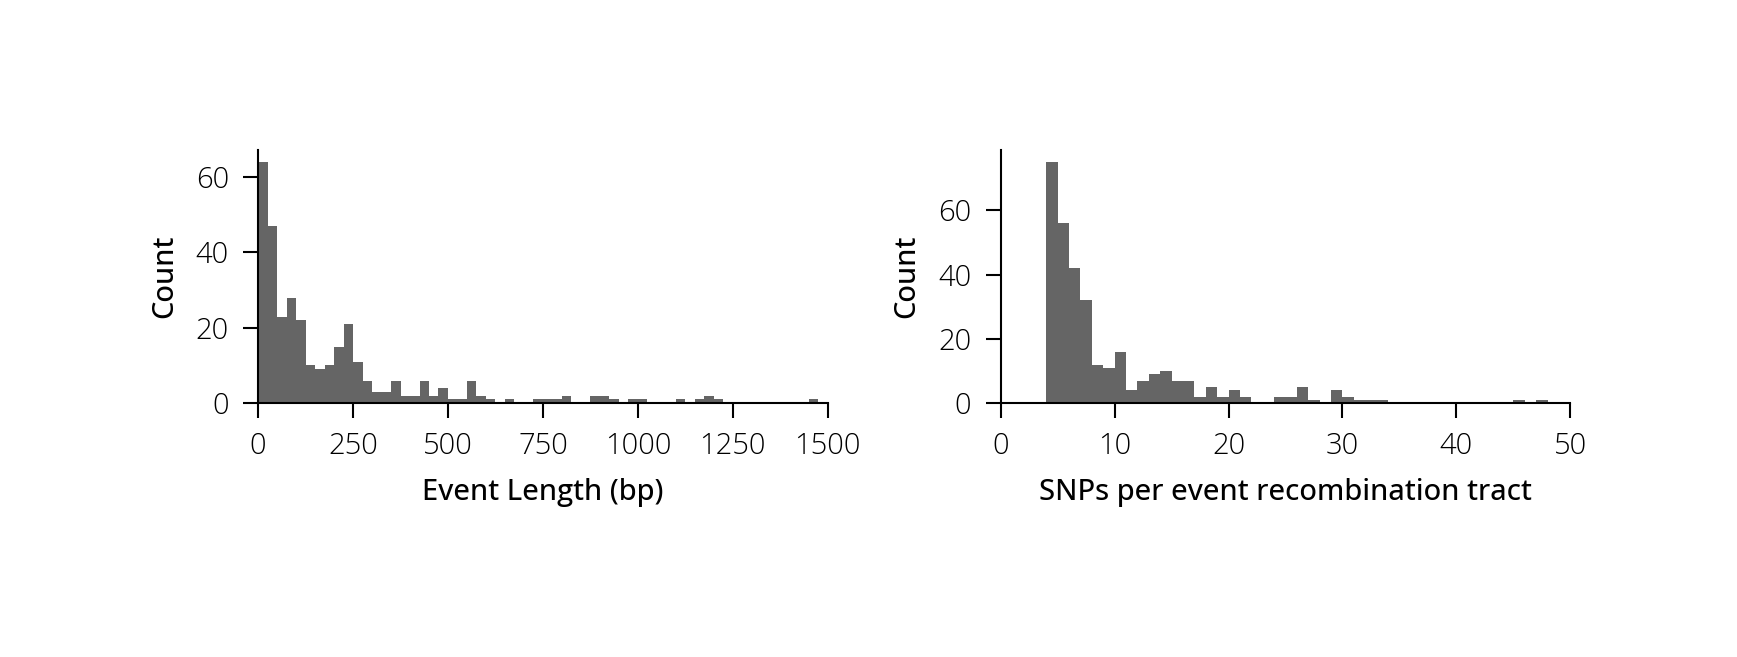

In [336]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 2, figsize=(5, 1.4), sharex=False)

# Histogram for EventLen
sns.histplot(GCE_All_DF["EventLen"], ax=axs[0], bins = np.arange(0, 1550, 25),
             color='black', alpha=0.6, edgecolor=None)
axs[0].set_xlim(0, 1500)
axs[0].set_xlabel("Event Length (bp)")
axs[0].set_ylabel("Count")

# Histogram for snp_count
sns.histplot(GCE_All_DF["snp_count"], ax=axs[1], bins = np.arange(0, 51), color='black', alpha=0.6, edgecolor=None)
axs[1].set_xlim(0, 50)
axs[1].set_xlabel("SNPs per event recombination tract")
axs[1].set_ylabel("Count")

#fig.suptitle("Recombination tract length and # of substitutions Iinferred across all putative gene conversion events (N = 324)", fontsize=6)

sns.despine()
plt.tight_layout()
plt.show()

fig.savefig("./GCE_Length_SNP_Dist_QC/GCE.All.LengthAndNumSNPs.Distr.svg")

# Part 4: Evaluate donor-acceptor distance of all mapped GCEs

In [337]:
GCE_Mapped_DF["DistToHm_TopKmatch"].describe()

count    1.880000e+02
mean     5.785927e+05
std      7.393418e+05
min      1.337000e+03
25%      3.414750e+03
50%      1.499625e+04
75%      9.202378e+05
max      2.139074e+06
Name: DistToHm_TopKmatch, dtype: float64

In [338]:
#GCE_Mapped_Only1TopMatch_DF = GCE_Mapped_DF.query("NumHm_AtMaxKmerMatch == 1")

In [339]:
#GCE_Mapped_Only1TopMatch_DF[ GCE_Mapped_Only1TopMatch_DF["DistToHm_TopKmatch"].isna() ].shape

In [340]:
#GCE_MatchToEachPR_DF.query("P_KmerMatch >= 0.5").shape

In [341]:
#GCE_MatchToEachPR_DF.query("P_KmerMatch > 0.5").shape

In [342]:
GCE_MatchToEachPR_DF.shape

(590, 15)

In [343]:
GCE_MatchToEachPR_DF.head(2)

,EventID,start_0based,end_1based,Overlap_Genes,HomologTargetID,Hm_Overlap_Genes,Target_Start,Target_End,NumMatch_SNPs,Total_SNPs,P_SNPMatch,NumMatch_Kmers,Total_Kmers,P_KmerMatch,Dist_Event_To_Hm
0,Event_001,103599,104478,"Rv0093c,Rv0094c","Rv1587c,Rv1588c-H37Rv-1788513-1789865","Rv1587c,Rv1588c",1788513,1789865,0,10,0.0,68,79,0.8608,1685150.5
1,Event_001,103599,104478,"Rv0093c,Rv0094c","Rv3466,Rv3467-H37Rv-3883535-3884921","Rv3466,Rv3467",3883535,3884921,0,10,0.0,68,79,0.8608,631342.5


In [344]:
GCE_MatchToEachPR_OnlyMapped_DF = GCE_MatchToEachPR_DF.query("P_KmerMatch >= 0.5")
GCE_MatchToEachPR_OnlyMapped_DF.shape

(263, 15)

In [345]:
#GCE_Mapped_DF.head(10)

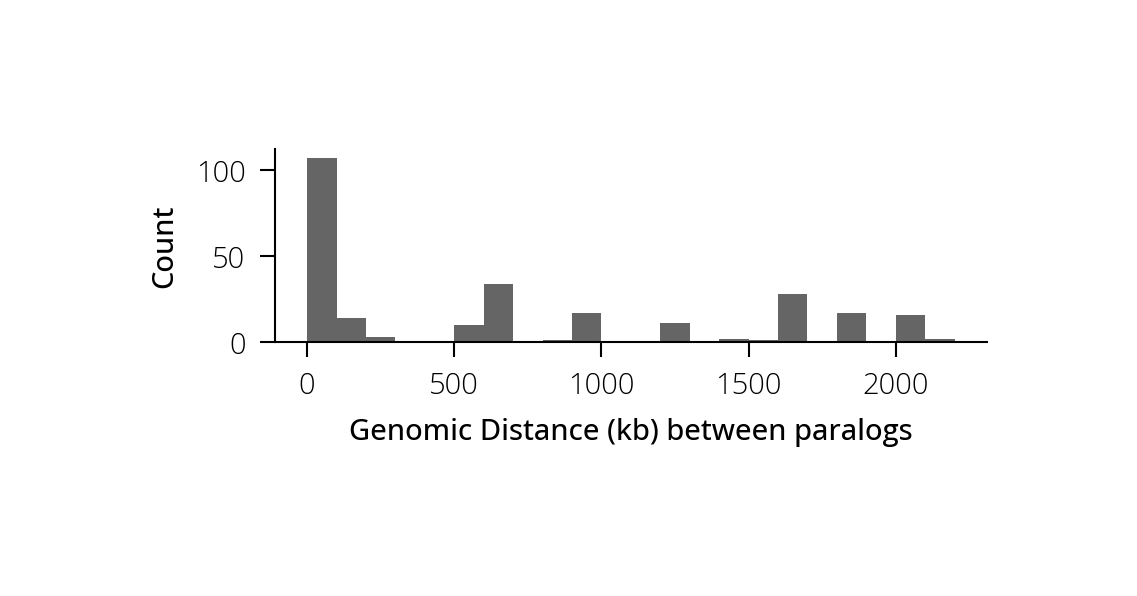

In [346]:
fig, ax = plt.subplots(1, 1, figsize=(3, 1.2), sharex=False)
axs = [ax]

sns.histplot(GCE_MatchToEachPR_OnlyMapped_DF["Dist_Event_To_Hm"], ax=axs[0], bins = np.arange(0, 2300000, 100000),
             color='black', alpha=0.6, edgecolor=None)

axs[0].ticklabel_format(style='plain', axis='x')
axs[0].set_xlabel("Distance between event and inferred donor paralog")
axs[0].set_ylabel("Count")
axs[0].xaxis.set_major_formatter(FuncFormatter(bp_to_kb))
axs[0].set_xlabel("Genomic Distance (kb) between paralogs")
#axs[0].set_title("Distances between Mapped GC events to inferred donor paralogs", fontsize=5)

sns.despine()
plt.tight_layout()
plt.show()

fig.savefig("./GCE_Length_SNP_Dist_QC/GCE.Mapped.DonorDist.Distr.svg")

# Part Y: Viz k-mer match distribution of all GCEs in PRs

In [347]:
GCE_ABM_DF.shape

(324, 47)

In [348]:
GCE_ABM_DF.shape

(324, 47)

In [351]:
GCE_InPR_DF.shape

(295, 47)

### Viz k-mer EventToParalog Match Score distribution

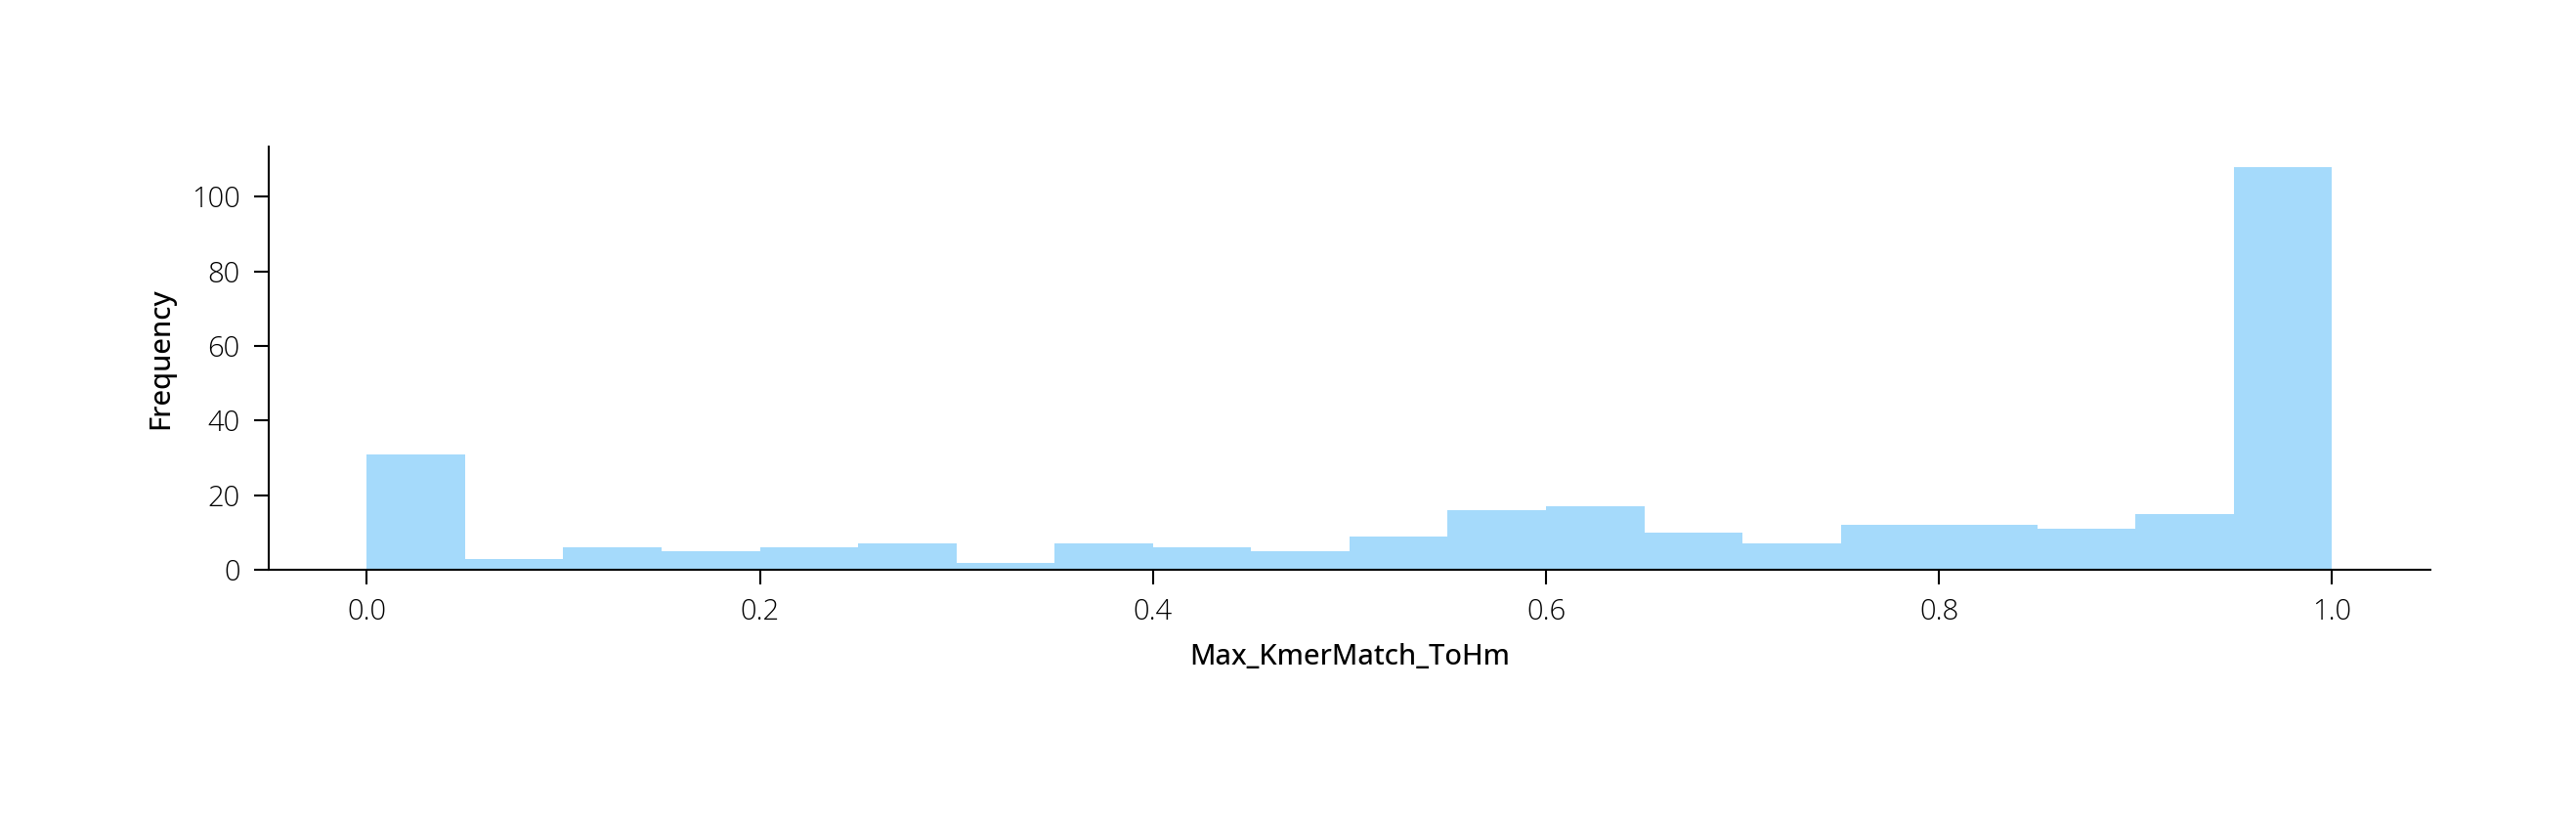

In [353]:
# Create a figure with 2 subplots stacked vertically
fig, ax1 = plt.subplots(1, 1, figsize=(8, 2))

# First subplot - Histogram
sns.histplot(GCE_InPR_DF["Max_KmerMatch_ToHm"],
             bins=np.arange(0, 1.05, 0.05), color="#87CEFA",
             ax=ax1)

sns.despine(ax=ax1)
ax1.set_ylabel("Frequency")

plt.tight_layout()
fig.savefig("./Fig3.GCE_Results/KmerMatchHisto.GCEs.v1.svg")

plt.show()

# Part X

# Extras